# **Supply Chain Analytics Lab**
## Projeto 1 — Predição de atraso para OTD (On Time Delivery) no momento da compra para apoiar a melhoria do OTIF

---

## 0. Setup Técnico
**Objetivo:** Preparar ambiente, autenticar no BigQuery e carregar a base analítica (vw_analise_otif).

In [1]:
# Bibliotecas base
import os
import pandas as pd
import numpy as np

# Visualizacao
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# Configuracoes de visualizacao e display
from IPython.display import display
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")

In [2]:
# Detecta ambiente (Colab ou local) e carrega dados
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_PATH = "/content/drive/MyDrive/Projetos/Supply_Chain_Analytics/Olist_dataset"
else:
    DATA_PATH = r"g:\Meu Drive\Projetos\Supply_Chain_Analytics\Olist_dataset"

date_cols = [
    "order_purchase_timestamp", "order_approved_at",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

orders    = pd.read_csv(os.path.join(DATA_PATH, "orders.csv"),   parse_dates=date_cols)
customers = pd.read_csv(os.path.join(DATA_PATH, "customers.csv"))
items     = pd.read_csv(os.path.join(DATA_PATH, "order_items.csv"))
sellers   = pd.read_csv(os.path.join(DATA_PATH, "sellers.csv"))
products  = pd.read_csv(os.path.join(DATA_PATH, "products.csv"))
geolocation = pd.read_csv(os.path.join(DATA_PATH, "geolocation.csv"))

print(f"Ambiente: {'Colab' if IN_COLAB else 'Local'}")
print(f"Arquivos carregados.")
print(f"Pedidos: {len(orders)} | Itens: {len(items)} | Clientes: {len(customers)} | Geoloc: {len(geolocation)}")

Mounted at /content/drive
Ambiente: Colab
Arquivos carregados.
Pedidos: 99441 | Itens: 112650 | Clientes: 99441 | Geoloc: 1000163


In [3]:
# 

# Primeiro item por pedido (garante 1 linha por order)
items_first = (
    items.sort_values("order_item_id")
    .groupby("order_id", as_index=False)
    .first()
)

# Join das tabelas
df = (
    orders[orders["order_status"] == "delivered"]
    .merge(customers[["customer_id", "customer_state"]], on="customer_id", how="left")
    .merge(items_first[["order_id", "seller_id", "price", "freight_value", "product_id"]], on="order_id", how="left")
    .merge(sellers[["seller_id", "seller_state"]], on="seller_id", how="left")
    .merge(products[["product_id", "product_category_name", "product_weight_g"]], on="product_id", how="left")
)

# Variaveis derivadas de tempo (dias)
df["seller_lead_time"] = (df["order_delivered_carrier_date"] - df["order_approved_at"]).dt.days
df["transport_lead_time"] = (df["order_delivered_customer_date"] - df["order_delivered_carrier_date"]).dt.days
df["time_variance"] = (df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]).dt.days
df["otif_on_time"] = (df["time_variance"] <= 0).astype("int8")

df = df.reset_index(drop=True)

In [4]:
print("Base carregada com sucesso.")
print(f"Quantidade de linhas: {df.shape[0]}")
print(f"Quantidade de colunas: {df.shape[1]}")
display(df.head(3))

Base carregada com sucesso.
Quantidade de linhas: 96478
Quantidade de colunas: 20


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_state,seller_id,price,freight_value,product_id,seller_state,product_category_name,product_weight_g,seller_lead_time,transport_lead_time,time_variance,otif_on_time
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,SP,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,87285b34884572647811a353c7ac498a,SP,utilidades_domesticas,500.0,2.0,6.0,-8.0,1
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,BA,289cdb325fb7e7f891c38608bf9e0962,118.70,22.76,595fac2a385ac33a80bd5114aec74eb8,SP,perfumaria,400.0,0.0,12.0,-6.0,1
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,GO,4869f7a5dfa277a7dca6462dcf3b52b2,159.90,19.22,aa4383b373c6aca5d8797843e5594415,SP,automotivo,420.0,0.0,9.0,-18.0,1


## 1. Definição do Problema

OTD (On Time Delivery) é um indicador logístico que mede se o pedido foi entregue no prazo prometido ao cliente.

OTIF (On-Time In-Full) é um indicador mais amplo, que considera se o pedido foi entregue no prazo e de forma completa.

Neste projeto, o objetivo é estimar a **probabilidade de atraso no momento da compra**, quando ainda é possível atuar preventivamente na operação.

**Target do modelo:** atraso do pedido (proxy operacional de OTD).  
**Indicador diretamente relacionado:** OTD.  
**Indicador de negócio apoiado indiretamente:** OTIF.  
**Momento da decisão:** aprovação do pedido (compra confirmada).  

**Premissa metodológica:**  
As variáveis usadas na previsão devem estar disponíveis no momento da decisão, evitando vazamento de dados (*data leakage*).

**Tradução prática do problema:**  
o modelo deve sinalizar, no momento da compra, quais pedidos têm maior risco de atraso para permitir ações preventivas e apoiar a melhoria do OTD e, indiretamente, do OTIF.

## 2. Entendimento dos Dados
**Objetivo:** Confirmar estrutura da base, tipos, volume, variáveis críticas e qualidade inicial antes da limpeza.

### 2.1 Estrutura Inicial

**Objetivo:** Validar volume, colunas e tipos de dados para garantir que a view analítica está consistente.

In [5]:
print("Primeiras 5 linhas da base:")
display(df.head(5))

Primeiras 5 linhas da base:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_state,seller_id,price,freight_value,product_id,seller_state,product_category_name,product_weight_g,seller_lead_time,transport_lead_time,time_variance,otif_on_time
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,SP,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,87285b34884572647811a353c7ac498a,SP,utilidades_domesticas,500.0,2.0,6.0,-8.0,1
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,BA,289cdb325fb7e7f891c38608bf9e0962,118.70,22.76,595fac2a385ac33a80bd5114aec74eb8,SP,perfumaria,400.0,0.0,12.0,-6.0,1
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,GO,4869f7a5dfa277a7dca6462dcf3b52b2,159.90,19.22,aa4383b373c6aca5d8797843e5594415,SP,automotivo,420.0,0.0,9.0,-18.0,1
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,RN,66922902710d126a0e7d26b0e3805106,45.00,27.20,d0b61bfb1de832b15ba9d266ca96e5b0,MG,pet_shop,450.0,3.0,9.0,-13.0,1
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,SP,2c9e548be18521d1c43cde1c582c6de8,19.90,8.72,65266b2da20d04dbe00c5c2d3bb7859e,SP,papelaria,250.0,0.0,1.0,-10.0,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96478 entries, 0 to 96477
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96478 non-null  object        
 1   customer_id                    96478 non-null  object        
 2   order_status                   96478 non-null  object        
 3   order_purchase_timestamp       96478 non-null  datetime64[ns]
 4   order_approved_at              96464 non-null  datetime64[ns]
 5   order_delivered_carrier_date   96476 non-null  datetime64[ns]
 6   order_delivered_customer_date  96470 non-null  datetime64[ns]
 7   order_estimated_delivery_date  96478 non-null  datetime64[ns]
 8   customer_state                 96478 non-null  object        
 9   seller_id                      96478 non-null  object        
 10  price                          96478 non-null  float64       
 11  freight_value  

### 2.2 Checagem de Nulos

**Objetivo:** Identificar campos críticos com ausência de dados e definir tratamento (remover, imputar ou manter como categoria “desconhecido”).

In [7]:
nulos_time_variance = df["time_variance"].isna().sum()
total = len(df)

print(f"Nulos em time_variance: {nulos_time_variance} ({nulos_time_variance/total:.2%})")

Nulos em time_variance: 8 (0.01%)


In [8]:
critical_columns = [
    "time_variance",
    "product_weight_g",
    "freight_value",
    "price",
    "customer_state",
    "seller_state",
    "seller_id",
    "product_category_name",
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

print("Nulos nas colunas críticas:")
display(df[critical_columns].isna().sum().sort_values(ascending=False))

Nulos nas colunas críticas:


,0
product_category_name,1359
product_weight_g,16
time_variance,8
order_delivered_customer_date,8
freight_value,0
price,0
customer_state,0
seller_id,0
seller_state,0
order_purchase_timestamp,0


## 3. Engenharia de Dados
**Objetivo:** Garantir consistência técnica sem remover fenômenos operacionais reais (ex.: atrasos extremos).

**Princípio (projeto real):**  
- Remover **impossibilidades físicas/cadastro** (ex.: peso ≤ 0).  
- Manter **eventos operacionais reais** (ex.: atrasos longos), pois são parte do problema.

### 3.1 Diagnóstico inicial (para definir regras)

**Objetivo:** Identificar valores extremos/impossíveis para orientar a limpeza técnica.

In [9]:
print("Estatísticas descritivas das variáveis numéricas:")
display(df.describe().T)

Estatísticas descritivas das variáveis numéricas:


,count,mean,min,25%,50%,75%,max,std
order_purchase_timestamp,96478,2018-01-01 23:29:31.939913984,2016-09-15 12:16:38,2017-09-14 09:00:23.249999872,2018-01-20 19:45:45,2018-05-05 18:54:47,2018-08-29 15:00:37,NaN
order_approved_at,96464,2018-01-02 10:53:23.338012160,2016-09-15 12:16:38,2017-09-14 14:48:54,2018-01-22 13:50:04,2018-05-06 10:57:24.750000128,2018-08-29 15:10:26,NaN
order_delivered_carrier_date,96476,2018-01-05 05:01:50.912330240,2016-10-08 10:34:01,2017-09-18 16:46:13.249999872,2018-01-24 16:13:47.500000,2018-05-08 14:35:00,2018-09-11 19:48:28,NaN
order_delivered_customer_date,96470,2018-01-14 12:41:33.581683456,2016-10-11 13:46:32,2017-09-25 22:15:09.500000,2018-02-02 19:32:21,2018-05-15 22:54:48.500000,2018-10-17 13:22:46,NaN
order_estimated_delivery_date,96478,2018-01-25 17:09:52.325711616,2016-10-04 00:00:00,2017-10-05 00:00:00,2018-02-16 00:00:00,2018-05-28 00:00:00,2018-10-25 00:00:00,NaN
price,96478.0,125.280336,0.85,41.3,79.0,139.9,6735.0,190.099465
freight_value,96478.0,20.160296,0.0,13.3,16.36,21.2,409.68,15.801311
product_weight_g,96462.0,2097.746968,0.0,300.0,700.0,1800.0,40425.0,3754.111279
seller_lead_time,96462.0,2.295712,-172.0,0.0,1.0,3.0,125.0,3.547926
transport_lead_time,96469.0,8.878054,-17.0,4.0,7.0,12.0,205.0,8.745881


**Leitura inicial das estatísticas numéricas**

A análise descritiva mostra que algumas variáveis apresentam sinais importantes para a etapa de limpeza e para a interpretação do problema.

- `product_weight_g`: o valor mínimo igual a `0` sugere existência de registros com peso impossível, o que indica erro de cadastro ou informação incompleta.
- `freight_value`: o mínimo igual a `0` pode representar frete subsidiado, promoção ou ausência de cobrança, mas também merece verificação para confirmar se não há inconsistência.
- `seller_lead_time` e `transport_lead_time`: a presença de valores negativos indica situações atípicas ou possíveis inconsistências de cálculo/data, exigindo análise cuidadosa antes de decidir remoção.
- `time_variance`: como possui valores negativos e positivos, confirma que existem pedidos entregues antes do prazo e também pedidos entregues com atraso. Essa variável será a base para a construção do alvo de atraso.
- `otif_on_time`: a média de aproximadamente `0.932` confirma que cerca de 93% dos pedidos foram entregues no prazo — a classe de atraso representa apenas ~7% dos casos, confirmando o forte desbalanceamento.

**Implicação para a próxima etapa:**  
Nem todo valor extremo será removido. O foco da limpeza será separar:
1. impossibilidades físicas ou erros claros de cadastro  
2. eventos operacionais raros, mas reais, que devem permanecer na base


In [10]:
print("Resumo descritivo das variáveis categóricas:")
display(df.select_dtypes(include="object").describe().T)

Resumo descritivo das variáveis categóricas:


,count,unique,top,freq
order_id,96478,96478,66dea50a8b16d9b4dee7af250b4be1a5,1
customer_id,96478,96478,edb027a75a1449115f6b43211ae02a24,1
order_status,96478,1,delivered,96478
customer_state,96478,27,SP,40501
seller_id,96478,2960,6560211a19b47992c3666cc44a7e94c0,1809
product_id,96478,31155,99a4788cb24856965c36a24e339b6058,428
seller_state,96478,22,SP,68421
product_category_name,95119,73,cama_mesa_banho,9167


**Leitura inicial das variáveis categóricas**

A análise das variáveis categóricas mostra sinais relevantes para entendimento do grão da base, concentração geográfica, qualidade dos dados e futura modelagem.

- `order_id`: existem `96.478` linhas, todas com pedidos únicos (`freq = 1`), confirmando que a base está no grão correto de um pedido por linha.
- `customer_state`: a base cobre os `27` estados brasileiros, com forte concentração em `SP`, o que indica distribuição geográfica desigual dos clientes.
- `seller_state`: existem `22` estados de origem dos vendedores, também com forte concentração em `SP`, sugerindo centralização operacional da malha de sellers.
- `product_category_name`: a contagem de registros não nulos (`95.119`) é menor que o total de linhas (`96.478`), indicando presença de `1.359` valores nulos nessa variável.
- `seller_id`: há `2.960` vendedores únicos, caracterizando alta cardinalidade. Essa característica exige cuidado na modelagem, especialmente em técnicas de codificação de variáveis categóricas.

**Implicações para as próximas etapas:**  
1. o grão da base já é um pedido por linha — não há duplicatas a tratar  
2. variáveis com alta cardinalidade, como `seller_id`, exigirão tratamento cuidadoso  
3. variáveis com nulos, como `product_category_name`, precisarão de decisão específica de tratamento

### 3.2 Remoção de Impossibilidades Físicas
**Objetivo:** Remover registros com valores impossíveis (ex.: peso <= 0), que representam erro de cadastro e distorcem a análise/modelagem.

In [11]:
df_clean = df.copy()

linhas_antes = len(df_clean)

df_clean = df_clean[df_clean["time_variance"].notna()].copy()
df_clean = df_clean[df_clean["order_purchase_timestamp"].notna()].copy()

df_clean = df_clean[df_clean["product_weight_g"].notna()].copy()
df_clean = df_clean[df_clean["product_weight_g"] > 0].copy()

df_clean = df_clean[df_clean["freight_value"].notna()].copy()
df_clean = df_clean[df_clean["freight_value"] >= 0].copy()

df_clean = df_clean[df_clean["price"].notna()].copy()
df_clean = df_clean[df_clean["price"] >= 0].copy()

df_clean["flag_seller_lead_time_negativo"] = (df_clean["seller_lead_time"] < 0).astype("int8")
df_clean["flag_transport_lead_time_negativo"] = (df_clean["transport_lead_time"] < 0).astype("int8")

linhas_depois = len(df_clean)
linhas_removidas = linhas_antes - linhas_depois

print(f"Linhas antes da limpeza: {linhas_antes}")
print(f"Linhas depois da limpeza: {linhas_depois}")
print(f"Linhas removidas: {linhas_removidas} ({linhas_removidas/linhas_antes:.2%})")
print(f"Seller lead time negativo: {df_clean['flag_seller_lead_time_negativo'].sum()}")
print(f"Transport lead time negativo: {df_clean['flag_transport_lead_time_negativo'].sum()}")

Linhas antes da limpeza: 96478
Linhas depois da limpeza: 96448
Linhas removidas: 30 (0.03%)
Seller lead time negativo: 1350
Transport lead time negativo: 23


**Resultado da limpeza:** Foram removidos registros sem informação mínima para definição do problema ou com inconsistências físicas claras, como peso inválido, preço negativo, frete negativo, ausência de `time_variance` ou ausência de `order_purchase_timestamp`.

**Decisão metodológica:** Eventos operacionais extremos, mas plausíveis, foram mantidos na base. Já casos suspeitos em variáveis temporais, como `seller_lead_time` e `transport_lead_time` negativos, foram sinalizados com flags para investigação posterior, sem remoção automática nesta etapa.

**Implicação estratégica:** A limpeza não busca “embelezar” os dados, mas separar ruído de cadastro de fenômenos reais da operação, preservando a capacidade analítica e preditiva do projeto.

### 3.3 Definição do alvo de atraso (OTD)

**Objetivo:** Construir a variável alvo do modelo a partir de `time_variance`, definindo de forma explícita quais pedidos ficaram no prazo e quais atrasaram.


In [12]:
df_clean["target_atraso"] = (df_clean["time_variance"] > 0).astype("int8")
df_clean["target_no_prazo"] = (df_clean["time_variance"] <= 0).astype("int8")

print("Distribuição do alvo de atraso:")
display(
    df_clean["target_atraso"]
    .value_counts(normalize=True)
    .sort_index()
    .rename("proporcao")
)

Distribuição do alvo de atraso:


,proporcao
target_atraso,
0,0.932254
1,0.067746


## 4. Análise Exploratória (EDA)
**Objetivo:** Identificar padrões operacionais relacionados ao atraso/OTD e validar hipóteses que orientarão decisões de modelagem e intervenção.

**Nota consultiva:** A EDA tem dois papéis neste projeto:
1. Diagnóstico operacional: entender onde o atraso tende a se concentrar.  
2. Direcionamento de modelagem: identificar sinais promissores para previsão no momento da compra e evitar armadilhas, como *data leakage*.

### 4.1 Distribuição da variável alvo (Atraso / OTD)

**Objetivo:** Quantificar o desbalanceamento do problema, medir a proporção de pedidos com atraso e dimensionar o volume de exceções operacionais.


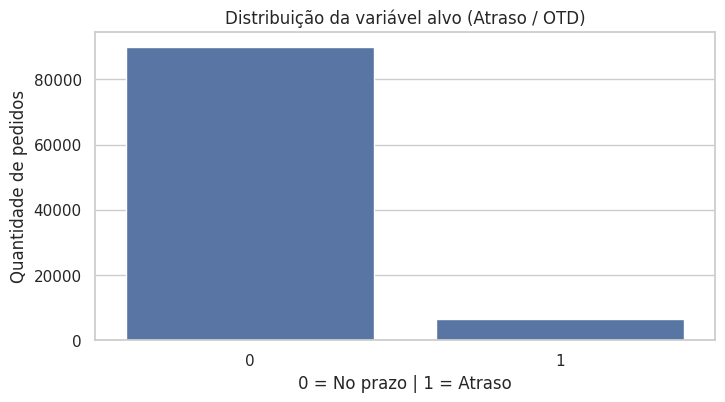

Taxa de atraso: 0.0677 (6.77%)
Taxa no prazo: 0.9323 (93.23%)


In [13]:
plt.figure(figsize=(8, 4))
sns.countplot(x="target_atraso", data=df_clean)
plt.title("Distribuição da variável alvo (Atraso / OTD)")
plt.xlabel("0 = No prazo | 1 = Atraso")
plt.ylabel("Quantidade de pedidos")
plt.show()

taxa_atraso = df_clean["target_atraso"].mean()
print(f"Taxa de atraso: {taxa_atraso:.4f} ({taxa_atraso*100:.2f}%)")
print(f"Taxa no prazo: {(1 - taxa_atraso):.4f} ({(1 - taxa_atraso)*100:.2f}%)")

**Resultado:** A base mostra que aproximadamente `6,77%` dos pedidos apresentaram atraso, enquanto `93,23%` permaneceram no prazo.

**Interpretação técnica:** Como `target_atraso` é uma variável binária (`0 = no prazo`, `1 = atraso`), sua média representa diretamente a taxa de atraso da operação. O resultado confirma que o problema é fortemente desbalanceado, com a classe de interesse (`atraso`) sendo minoritária.

**Implicação estratégica:** O valor do projeto está em antecipar essa minoria de exceções operacionais. Por isso, a modelagem não deve ser avaliada apenas por acurácia, mas também por métricas mais sensíveis à classe minoritária, como recall, precision, F1-score e PR-AUC.

### 4.2 Peso do produto influencia atraso?
**Objetivo:** Testar a hipótese operacional comum de que produtos mais pesados atrasam mais.

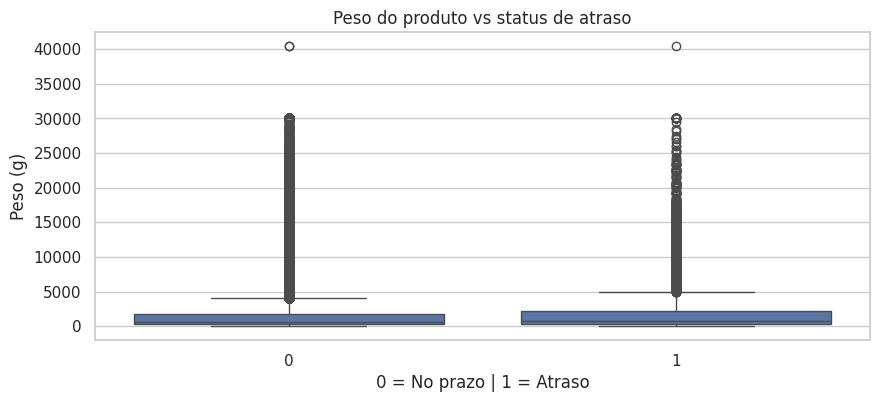

In [14]:
plt.figure(figsize=(10, 4))
sns.boxplot(x="target_atraso", y="product_weight_g", data=df_clean)
plt.title("Peso do produto vs status de atraso")
plt.xlabel("0 = No prazo | 1 = Atraso")
plt.ylabel("Peso (g)")
plt.show()

**Resultado:** As distribuições (mediana e dispersão) são semelhantes entre pedidos no prazo e atrasados.

**Interpretação técnica:** Não há evidência visual de separação relevante por peso. Isso sugere que peso isoladamente tem baixo poder discriminativo para prever atraso.

**Implicação estratégica:** Peso não deve ser tratado como “causa raiz” principal nem como prioridade operacional. É mais provável que o atraso esteja associado a geografia, capacidade e tempo/processo.

### 4.3 Lead time do vendedor vs lead time do transporte (diagnóstico)
**Objetivo:** Identificar em qual etapa do fluxo (vendedor/expedição vs transporte) o atraso tende a se concentrar.

**Importante:** Este diagnóstico usa variáveis pós-evento. Ele é útil para entender gargalo, mas não é elegível como feature se a previsão for no momento da compra.

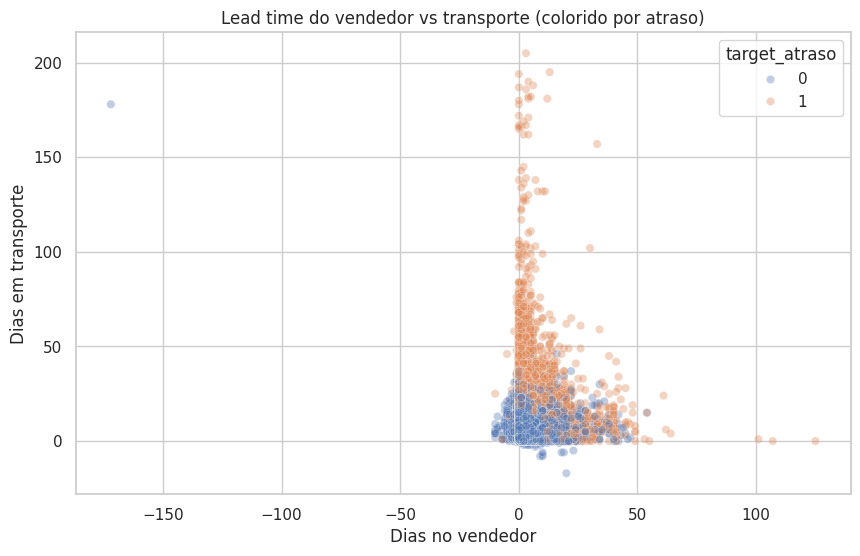

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x="seller_lead_time",
    y="transport_lead_time",
    hue="target_atraso",
    data=df_clean,
    alpha=0.35
)
plt.title("Lead time do vendedor vs transporte (colorido por atraso)")
plt.xlabel("Dias no vendedor")
plt.ylabel("Dias em transporte")
plt.show()

**Resultado:** Os pontos associados a atraso tendem a se concentrar em regiões com `transport_lead_time` mais elevado, mesmo quando o `seller_lead_time` permanece relativamente baixo.

**Interpretação técnica:** O gráfico sugere que o gargalo mais visível da operação está no transporte, e não predominantemente na etapa do vendedor. Ainda assim, existem casos dispersos em que ambos os tempos aumentam, indicando que o atraso pode resultar da combinação de múltiplas etapas.

**Implicação estratégica:** Para diagnóstico operacional, a malha de transporte parece ser prioridade de investigação. No entanto, como essas variáveis são pós-evento, elas devem permanecer fora do modelo preditivo no momento da compra.

### 4.4 Onde o atraso se concentra? (Top estados)
**Objetivo:** Verificar se o atraso é difuso ou concentrado regionalmente, para priorização de intervenção.

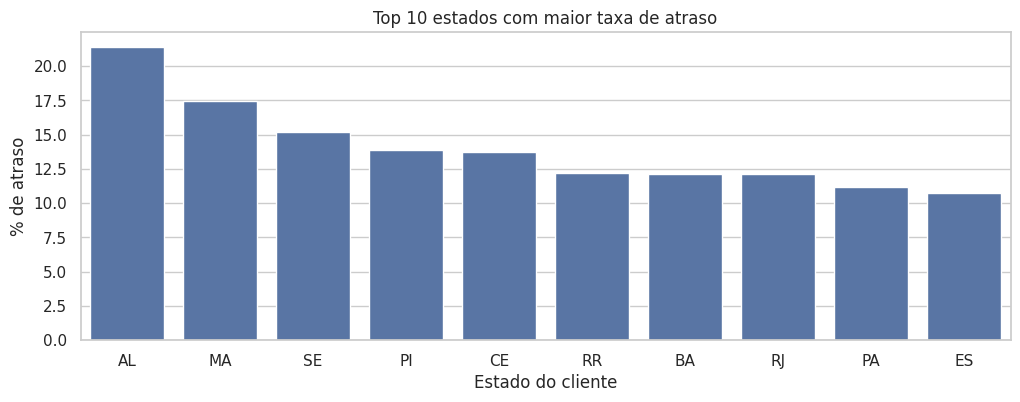

,taxa_atraso_pct
customer_state,
AL,21.41
MA,17.43
SE,15.22
PI,13.89
CE,13.76
RR,12.20
BA,12.17
RJ,12.11
PA,11.21


In [16]:
taxa_atraso_estado = (
    df_clean.groupby("customer_state")["target_atraso"]
    .mean()
    .sort_values(ascending=False)
)

top10 = (taxa_atraso_estado.head(10) * 100).round(2)

plt.figure(figsize=(12, 4))
sns.barplot(x=top10.index, y=top10.values)
plt.title("Top 10 estados com maior taxa de atraso")
plt.xlabel("Estado do cliente")
plt.ylabel("% de atraso")
plt.show()

display(top10.rename("taxa_atraso_pct").to_frame())

**Resultado:** O atraso não se distribui de forma homogênea entre os estados. No resultado atual, estados como `AL` (`21,41%`), `MA` (`17,43%`) e `SE` (`15,22%`) aparecem com taxas bem acima da média geral da base (`6,77%`).

**Interpretação técnica:** A variabilidade por estado reforça que fatores geográficos e logísticos influenciam o risco de atraso. Esse efeito pode refletir distância, qualidade da malha, capacidade regional, disponibilidade de transportadoras e características específicas das rotas.

**Leitura metodológica:** A taxa de atraso por estado é um sinal importante, mas deve ser interpretada junto com o volume de pedidos. Estados com taxa muito alta e baixo volume podem gerar percentuais instáveis, enquanto estados com taxa alta e grande volume representam prioridade operacional ainda maior.

**Implicação estratégica:** A ação mais eficiente é priorizar regiões e rotas críticas, em vez de tratar o problema como homogêneo em toda a operação. Para a modelagem, isso reforça o valor de variáveis geográficas e de históricos por rota ou região.

### 4.5 Correlação entre variáveis numéricas
**Objetivo:** Avaliar relações lineares e identificar possíveis sinais associados ao atraso/OTD, sem inferir causalidade.

**Nota:** Correlação é apenas uma lente rápida. Relações não lineares e interações entre variáveis (ex.: rota × sazonalidade) não aparecem bem nessa análise.

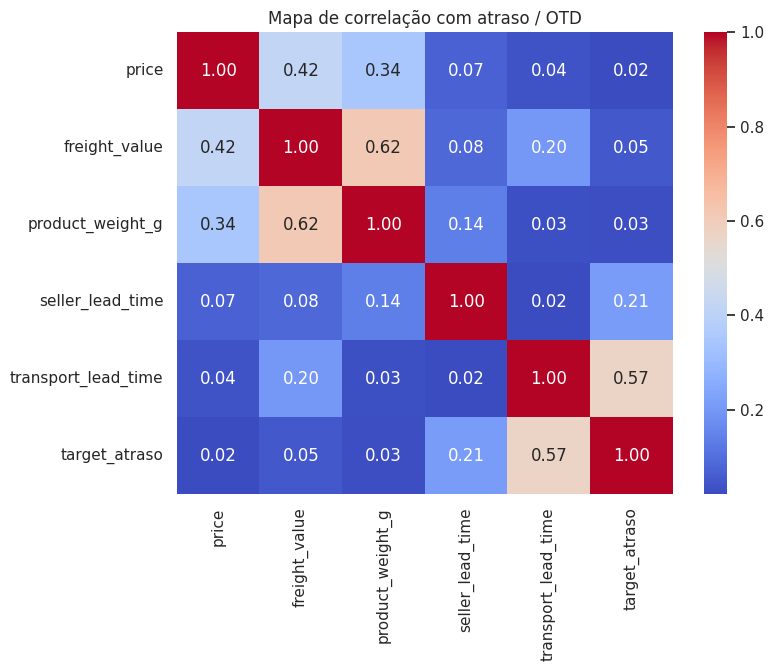

In [17]:
cols_corr = [
    "price",
    "freight_value",
    "product_weight_g",
    "seller_lead_time",
    "transport_lead_time",
    "target_atraso"
]

corr = df_clean[cols_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Mapa de correlação com atraso / OTD")
plt.show()

**Resultado:** Variáveis físicas e financeiras tendem a apresentar correlação linear fraca com o atraso, enquanto as variáveis de tempo mostram associação mais visível no diagnóstico.

**Interpretação técnica:** A matriz de correlação sugere que sinais como `price`, `freight_value` e `product_weight_g` isoladamente têm baixo poder explicativo linear para o atraso. Já `seller_lead_time` e `transport_lead_time` tendem a apresentar relação mais forte, mas devem ser interpretados apenas como variáveis diagnósticas, pois são pós-evento.

**Implicação estratégica:** A modelagem deve priorizar sinais disponíveis no momento da compra e ser capaz de capturar interações e não linearidades. Isso reforça o valor de variáveis geográficas, temporais e históricas, além de algoritmos flexíveis como XGBoost ou CatBoost.

## 5. Escopo Preditivo e Regra de Elegibilidade

**Objetivo:** Fixar o momento da previsão e definir quais variáveis podem ser usadas no modelo.

**Momento da previsão:** aprovação do pedido (compra confirmada).  
**Target do modelo:** atraso do pedido / OTD.  
**Regra de elegibilidade:** somente variáveis conhecidas nesse momento podem entrar como feature.

**Variáveis não elegíveis como feature:** informações observadas após a compra, como `seller_lead_time`, `transport_lead_time`, `time_variance`, `order_delivered_customer_date`, `order_estimated_delivery_date` e qualquer resultado final do pedido.

**Uso metodológico permitido:** `order_delivered_customer_date` e `order_estimated_delivery_date` podem ser usadas apenas como colunas auxiliares de controle temporal para definir quando o desfecho do pedido se tornou observável e, assim, permitir a construção correta de features históricas sem *data leakage*.

**Risco metodológico:** usar variáveis pós-evento como feature melhora artificialmente as métricas no notebook e produz um modelo que tende a falhar em produção.


## 6. Engenharia de Atributos
**Objetivo:** Construir features disponíveis no momento da compra (tempo, geografia e históricos sem vazamento).

### 6.1 Features temporais
**Objetivo:** Capturar sazonalidade e padrões operacionais associados ao momento da compra.

In [18]:
df_clean["order_purchase_timestamp"] = pd.to_datetime(df_clean["order_purchase_timestamp"])

df_clean["weekday"] = df_clean["order_purchase_timestamp"].dt.weekday.astype("int8")
df_clean["month"] = df_clean["order_purchase_timestamp"].dt.month.astype("int8")
df_clean["time_to_buy"] = df_clean["order_purchase_timestamp"].dt.hour.astype("int8")
df_clean["weekend"] = (df_clean["weekday"] >= 5).astype("int8")

display(df_clean[["order_purchase_timestamp", "weekday", "month", "time_to_buy", "weekend"]].head())

,order_purchase_timestamp,weekday,month,time_to_buy,weekend
0,2017-10-02 10:56:33,0,10,10,0
1,2018-07-24 20:41:37,1,7,20,0
2,2018-08-08 08:38:49,2,8,8,0
3,2017-11-18 19:28:06,5,11,19,1
4,2018-02-13 21:18:39,1,2,21,0


**Justificativa técnica:** Essas variáveis existem no momento da compra e funcionam como proxies de sazonalidade/carga operacional.

**Implicação estratégica:** Permite mapear risco por janelas de compra (ex.: finais de semana, horários) e orientar planejamento de capacidade/SLAs.

### 6.2 Feature de rota (origem → destino)
**Objetivo:** Capturar o efeito combinado de origem e destino, geralmente determinante em performance logística.

In [19]:
df_clean["route"] = (
    df_clean["seller_state"].astype(str)
    + "_"
    + df_clean["customer_state"].astype(str)
)

print("Quantidade de rotas únicas:", df_clean["route"].nunique())
display(df_clean[["seller_state", "customer_state", "route"]].head())

Quantidade de rotas únicas: 409


,seller_state,customer_state,route
0,SP,SP,SP_SP
1,SP,BA,SP_BA
2,SP,GO,SP_GO
3,MG,RN,MG_RN
4,SP,SP,SP_SP


**Justificativa técnica:** A rota representa a interação origem-destino (SP→RJ é diferente de SP→AM). Ela pode ser usada diretamente (encoding) ou como base para históricos por rota.

**Implicação estratégica:** Ajuda a priorizar corredores logísticos críticos e orientar SLAs/contratos por rota.

### 6.3 Features históricas (sem vazamento)
**Objetivo:** Criar sinais históricos de risco por rota e por seller usando apenas informação disponível antes de cada pedido.

**Regra metodológica:** a estatística histórica usada em cada observação deve ser calculada somente com dados anteriores ao instante do pedido (*t-1*), sem usar o próprio resultado da linha atual nem informações futuras.

**Implementação:** a construção correta dessas variáveis será feita na **ETAPA 8 — Engenharia Temporal Correta**.

### 6.4 Checagens rápidas
**Objetivo:** Garantir consistência do dataset preparado antes de avançar para engenharia temporal.

In [20]:
print("Taxa média de atraso:", round(df_clean["target_atraso"].mean(), 4))
print("Rotas únicas:", df_clean["route"].nunique())

print("Distribuição por dia da semana (volume):")
display(
    df_clean["weekday"]
    .value_counts()
    .sort_index()
    .rename("qtd_pedidos")
    .to_frame()
)

print("Taxa de atraso por dia da semana:")
display(
    (df_clean.groupby("weekday")["target_atraso"].mean() * 100)
    .round(2)
    .sort_values(ascending=False)
    .rename("taxa_atraso_pct")
    .to_frame()
)

Taxa média de atraso: 0.0677
Rotas únicas: 409
Distribuição por dia da semana (volume):


,qtd_pedidos
weekday,
0,15697
1,15501
2,15072
3,14319
4,13683
5,10550
6,11626


Taxa de atraso por dia da semana:


,taxa_atraso_pct
weekday,
0,7.44
1,7.05
4,7.02
5,6.60
2,6.57
3,6.31
6,6.23


### 6.5 Checklist anti-leakage (features permitidas vs proibidas)

**Permitidas como feature (momento da compra):**
- `seller_state`, `customer_state`, `route`
- `product_weight_g`, `price`, `freight_value`
- `order_purchase_timestamp` e derivados (`weekday`, `month`, `time_to_buy`, `weekend`)
- históricos calculados corretamente até *t-1* (a construir na seção 8)

**Proibidas como feature (pós-evento):**
- `transport_lead_time` final
- `seller_lead_time` final
- `time_variance`
- `order_delivered_customer_date`
- `order_estimated_delivery_date`
- qualquer atributo derivado do que aconteceu após a compra

**Permitidas como apoio metodológico na engenharia temporal:**
- `order_delivered_customer_date`
- `order_estimated_delivery_date`

Essas colunas não entram no modelo, mas podem ser usadas para definir o instante em que o resultado do pedido passou a ser conhecido e, com isso, construir features históricas causalmente corretas.

**Justificativa:** usar variáveis pós-evento como feature transforma o modelo em um reconhecedor do passado; usar essas mesmas colunas apenas para controle temporal ajuda a evitar vazamento.

### 6.6 Prazo prometido para entrega (dias)

**Objetivo:** Criar feature representando quantos dias a Olist prometeu para entregar o pedido a partir do momento da compra.

**Origem:** `order_estimated_delivery_date` − `order_purchase_timestamp`

**Por que não é leakage:** a data estimada é comunicada ao cliente no ato da compra — está disponível antes de qualquer evento logístico. É diferente de `time_variance`, que compara com a entrega real (pós-evento).

**Por que tem alto poder preditivo:** o algoritmo da Olist calcula o prazo considerando rota, carrier e histórico. Prazos mais longos indicam maior incerteza logística — o próprio sistema já embute esse sinal.

In [21]:
# 6.6 Prazo prometido em dias
df_clean["prazo_prometido_dias"] = (
    pd.to_datetime(df_clean["order_estimated_delivery_date"]) -
    pd.to_datetime(df_clean["order_purchase_timestamp"])
).dt.days

mediana_prazo = df_clean["prazo_prometido_dias"].median()
df_clean["prazo_prometido_dias"] = df_clean["prazo_prometido_dias"].fillna(mediana_prazo)

print("prazo_prometido_dias — estatísticas:")
print(df_clean["prazo_prometido_dias"].describe().round(1))
print(f"Nulos: {df_clean['prazo_prometido_dias'].isna().sum()}")

prazo_prometido_dias — estatísticas:
count    96448.0
mean        23.4
std          8.8
min          2.0
25%         18.0
50%         23.0
75%         28.0
max        155.0
Name: prazo_prometido_dias, dtype: float64
Nulos: 0


### 6.7 Distância geográfica seller → customer (km)

**Objetivo:** Estimar a distância física entre vendedor e cliente usando coordenadas geográficas por prefixo de CEP.

**Fonte:** `geolocation.csv` — latitude e longitude de prefixos de CEP brasileiros.

**Por que não é leakage:** CEP do seller e do customer são conhecidos no momento da compra.

**Por que tem alto poder preditivo:** distância é proxy direto da complexidade logística — rotas longas têm mais pontos de falha, maior dependência de modais e variabilidade de prazo.

**Fórmula:** Haversine — distância de arco entre dois pontos na superfície terrestre.

In [22]:
# 6.7 Distância haversine seller → customer

# Mediana de lat/lon por prefixo de CEP (múltiplos registros por CEP no dataset)
geo_median = (
    geolocation
    .groupby("geolocation_zip_code_prefix")[["geolocation_lat", "geolocation_lng"]]
    .median()
    .reset_index()
)

# Adicionar prefixos de CEP via join nas bases originais
df_clean = df_clean.merge(
    customers[["customer_id", "customer_zip_code_prefix"]], on="customer_id", how="left"
).merge(
    sellers[["seller_id", "seller_zip_code_prefix"]], on="seller_id", how="left"
)

# Coordenadas do seller
df_clean = df_clean.merge(
    geo_median.rename(columns={
        "geolocation_zip_code_prefix": "seller_zip_code_prefix",
        "geolocation_lat": "seller_lat",
        "geolocation_lng": "seller_lng",
    }),
    on="seller_zip_code_prefix", how="left"
)

# Coordenadas do customer
df_clean = df_clean.merge(
    geo_median.rename(columns={
        "geolocation_zip_code_prefix": "customer_zip_code_prefix",
        "geolocation_lat": "customer_lat",
        "geolocation_lng": "customer_lng",
    }),
    on="customer_zip_code_prefix", how="left"
)

# Haversine
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = (np.sin(dlat / 2)**2
         + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon / 2)**2)
    return R * 2 * np.arcsin(np.sqrt(a))

df_clean["distancia_km"] = haversine_km(
    df_clean["seller_lat"], df_clean["seller_lng"],
    df_clean["customer_lat"], df_clean["customer_lng"]
)

# Preencher nulos (CEPs sem match) com mediana
mediana_dist = df_clean["distancia_km"].median()
df_clean["distancia_km"] = df_clean["distancia_km"].fillna(mediana_dist)

# Remover colunas auxiliares
df_clean = df_clean.drop(columns=[
    "seller_zip_code_prefix", "customer_zip_code_prefix",
    "seller_lat", "seller_lng", "customer_lat", "customer_lng"
])

print("distancia_km — estatísticas:")
print(df_clean["distancia_km"].describe().round(1))
print(f"Nulos: {df_clean['distancia_km'].isna().sum()}")

distancia_km — estatísticas:
count    96448.0
mean       599.8
std        592.8
min          0.0
25%        188.3
50%        433.8
75%        795.7
max       8677.9
Name: distancia_km, dtype: float64
Nulos: 0


## 7. Preparação para Modelagem

**Objetivo:** Definir os princípios de avaliação do modelo antes do treino.

**Diretrizes desta etapa:**
- o split deve ser temporal, respeitando a ordem dos pedidos
- o problema é desbalanceado, então acurácia isolada não basta
- a avaliação deve priorizar métricas adequadas para a classe minoritária, como recall, precision, F1-score e PR-AUC

**Justificativa metodológica:** como a previsão acontece no momento da compra, o treino deve usar o passado e o teste deve simular pedidos futuros.

## 8. Engenharia Temporal Causal das Features Históricas

**Objetivo:** Construir features históricas de risco de atraso por rota e por seller que sejam realmente observáveis no momento da compra, evitando *data leakage*.

**Princípio causal:** Para cada pedido em `t`, o histórico só pode usar pedidos cujo desfecho já era conhecido antes de `t`.

**Marco temporal do desfecho (`label_known_at`):** o instante em que o resultado do pedido passou a ser observável será definido a partir de `order_delivered_customer_date` e `order_estimated_delivery_date`. Essas colunas serão usadas apenas para controle temporal, e não como features do modelo.

**Entregáveis desta etapa:**
- `label_known_at`: instante em que o desfecho do pedido passou a ser conhecido
- `hist_atraso_route_t`: taxa histórica de atraso da rota usando apenas pedidos já observáveis
- `hist_atraso_seller_t`: taxa histórica de atraso do seller usando apenas pedidos já observáveis
- `prior_global_atraso`: taxa global de atraso usada em situações de *cold start*
- validações anti-leakage e checagens de consistência temporal

### 8.1 Preparação temporal e contrato causal mínimo

**Objetivo:** Garantir que:
1. `order_purchase_timestamp` está em formato datetime  
2. `order_delivered_customer_date` e `order_estimated_delivery_date` estão disponíveis para definir quando o desfecho passou a ser observável  
3. as colunas necessárias para criar os históricos existem  
4. não há registros sem timestamp de compra  
5. a base pode ser organizada de forma consistente para construção causal das features históricas

**Por que isso importa:** nesta etapa, não basta ordenar pedidos no tempo. É necessário distinguir o instante da compra do instante em que o resultado do pedido se tornou conhecido, para evitar *data leakage* na construção dos históricos.

In [23]:
df_t = df_clean.copy()

datetime_cols = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

for col in datetime_cols:
    df_t[col] = pd.to_datetime(df_t[col], errors="coerce")

required_cols = [
    "order_id",
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "route",
    "seller_id",
    "target_atraso",
]

missing = [c for c in required_cols if c not in df_t.columns]
if missing:
    raise ValueError(f"Colunas obrigatórias ausentes para a seção 9: {missing}")

df_t["label_known_at"] = df_t[
    ["order_delivered_customer_date", "order_estimated_delivery_date"]
].min(axis=1)

n_purchase_null = df_t["order_purchase_timestamp"].isna().sum()
n_label_null = df_t["label_known_at"].isna().sum()
n_label_before_purchase = (
    df_t["order_purchase_timestamp"].notna()
    & df_t["label_known_at"].notna()
    & (df_t["label_known_at"] < df_t["order_purchase_timestamp"])
).sum()

print(f"Compra sem timestamp válido: {n_purchase_null}")
print(f"Sem label_known_at: {n_label_null}")
print(f"label_known_at antes da compra: {n_label_before_purchase}")

mask_valida = (
    df_t["order_purchase_timestamp"].notna()
    & df_t["label_known_at"].notna()
    & (df_t["label_known_at"] >= df_t["order_purchase_timestamp"])
)

df_t = df_t.loc[mask_valida].copy()

df_t = df_t.sort_values(
    ["order_purchase_timestamp", "label_known_at", "order_id"]
).reset_index(drop=True)

display(
    df_t[
        [
            "order_id",
            "order_purchase_timestamp",
            "order_estimated_delivery_date",
            "order_delivered_customer_date",
            "label_known_at",
            "route",
            "seller_id",
            "target_atraso",
        ]
    ].head(10)
)


Compra sem timestamp válido: 0
Sem label_known_at: 0
label_known_at antes da compra: 0


,order_id,order_purchase_timestamp,order_estimated_delivery_date,order_delivered_customer_date,label_known_at,route,seller_id,target_atraso
0,bfbd0f9bdef84302105ad712db648a6c,2016-09-15 12:16:38,2016-10-04,2016-11-09 07:47:38,2016-10-04 00:00:00,PR_SP,ecccfa2bb93b34a3bf033cc5d1dcdc69,1
1,3b697a20d9e427646d92567910af6d57,2016-10-03 09:44:50,2016-10-27,2016-10-26 14:02:13,2016-10-26 14:02:13,PR_SP,522620dcb18a6b31cd7bdf73665113a9,0
2,be5bc2f0da14d8071e2d45451ad119d9,2016-10-03 16:56:50,2016-11-07,2016-10-27 18:19:38,2016-10-27 18:19:38,SP_RS,f09b760d23495ac9a7e00d29b769007c,0
3,a41c8759fbe7aab36ea07e038b2d4465,2016-10-03 21:13:36,2016-11-29,2016-11-03 10:58:07,2016-11-03 10:58:07,SP_RS,45d33f715e24d15a6ccf5c17b3a23e3c,0
4,d207cc272675637bfed0062edffd0818,2016-10-03 22:06:03,2016-11-23,2016-10-31 11:07:42,2016-10-31 11:07:42,SP_SP,cca3071e3e9bb7d12640c9fbe2301306,0
5,cd3b8574c82b42fc8129f6d502690c3e,2016-10-03 22:31:31,2016-11-23,2016-10-14 16:08:00,2016-10-14 16:08:00,SP_SP,b499c00f28f4b7069ff6550af8c1348a,0
6,ae8a60e4b03c5a4ba9ca0672c164b181,2016-10-03 22:44:10,2016-12-01,2016-11-03 14:04:50,2016-11-03 14:04:50,SP_GO,817f85dbb65aa3e70831d90fe75cdf89,0
7,ef1b29b591d31d57c0d7337460dd83c9,2016-10-03 22:51:30,2016-11-25,2016-11-01 15:14:45,2016-11-01 15:14:45,SP_MG,cca3071e3e9bb7d12640c9fbe2301306,0
8,0a0837a5eee9e7a9ce2b1fa831944d27,2016-10-04 09:06:10,2016-11-24,2016-10-22 14:51:18,2016-10-22 14:51:18,SP_SP,3481aa57cd91f9f9d3fa1fa12d9a3bf7,0
9,1ff217aa612f6cd7c4255c9bfe931c8b,2016-10-04 09:16:33,2016-11-24,2016-10-24 16:33:45,2016-10-24 16:33:45,SP_SP,4b1eaadf791bdbbad8c4a35b65236d52,0


### 8.2 Prior Global Causal (Cold Start)

**Objetivo:** Definir uma referência inicial de risco de atraso quando uma rota ou seller ainda não possui histórico observável.

Ao criar features históricas, a primeira ocorrência de uma rota ou seller não possui passado suficiente para calcular uma taxa própria. Nesses casos, utilizamos um **prior global causal**.

Esse prior representa a taxa global de atraso observável até o instante da compra analisada, e não a média calculada sobre toda a base.

Ele funciona como uma estimativa inicial de risco até que o grupo acumule histórico próprio, evitando vieses de *cold start* sem introduzir *data leakage*.

In [24]:
eventos_globais = (
    df_t.groupby("label_known_at", as_index=False)
    .agg(
        n_observado=("target_atraso", "size"),
        soma_atraso=("target_atraso", "sum"),
    )
    .sort_values("label_known_at")
    .rename(columns={"label_known_at": "known_at_reference"})
)

In [25]:
eventos_globais["n_observado_cum"] = eventos_globais["n_observado"].cumsum()
eventos_globais["soma_atraso_cum"] = eventos_globais["soma_atraso"].cumsum()
eventos_globais["prior_global_atraso_t"] = (
    eventos_globais["soma_atraso_cum"] / eventos_globais["n_observado_cum"]
    )

In [26]:
df_t = pd.merge_asof(
    df_t.sort_values(["order_purchase_timestamp", "label_known_at", "order_id"]),
    eventos_globais[
        ["known_at_reference", "n_observado_cum", "prior_global_atraso_t"]
    ].sort_values("known_at_reference"),
    left_on="order_purchase_timestamp",
    right_on="known_at_reference",
    direction="backward",
    allow_exact_matches=False,
)

In [27]:
prior_inicial_neutro = 0.50
df_t["prior_global_atraso_t"] = df_t["prior_global_atraso_t"].fillna(prior_inicial_neutro)
df_t["n_observado_cum"] = df_t["n_observado_cum"].fillna(0).astype("int64")

print(f"Prior inicial neutro: {prior_inicial_neutro:.2f}")
print("Linhas sem histórico global observável:", (df_t["n_observado_cum"] == 0).sum())

display(
    df_t[
        [
            "order_id",
            "order_purchase_timestamp",
            "label_known_at",
            "known_at_reference",
            "n_observado_cum",
            "prior_global_atraso_t",
            "target_atraso",
        ]
    ].head(10)
)

Prior inicial neutro: 0.50
Linhas sem histórico global observável: 8


,order_id,order_purchase_timestamp,label_known_at,known_at_reference,n_observado_cum,prior_global_atraso_t,target_atraso
0,bfbd0f9bdef84302105ad712db648a6c,2016-09-15 12:16:38,2016-10-04 00:00:00,NaT,0,0.5,1
1,3b697a20d9e427646d92567910af6d57,2016-10-03 09:44:50,2016-10-26 14:02:13,NaT,0,0.5,0
2,be5bc2f0da14d8071e2d45451ad119d9,2016-10-03 16:56:50,2016-10-27 18:19:38,NaT,0,0.5,0
3,a41c8759fbe7aab36ea07e038b2d4465,2016-10-03 21:13:36,2016-11-03 10:58:07,NaT,0,0.5,0
4,d207cc272675637bfed0062edffd0818,2016-10-03 22:06:03,2016-10-31 11:07:42,NaT,0,0.5,0
5,cd3b8574c82b42fc8129f6d502690c3e,2016-10-03 22:31:31,2016-10-14 16:08:00,NaT,0,0.5,0
6,ae8a60e4b03c5a4ba9ca0672c164b181,2016-10-03 22:44:10,2016-11-03 14:04:50,NaT,0,0.5,0
7,ef1b29b591d31d57c0d7337460dd83c9,2016-10-03 22:51:30,2016-11-01 15:14:45,NaT,0,0.5,0
8,0a0837a5eee9e7a9ce2b1fa831944d27,2016-10-04 09:06:10,2016-10-22 14:51:18,2016-10-04,1,1.0,0
9,1ff217aa612f6cd7c4255c9bfe931c8b,2016-10-04 09:16:33,2016-10-24 16:33:45,2016-10-04,1,1.0,0


### 8.3 Histórico causal de atraso por rota

**Objetivo:** Criar uma feature que represente o risco histórico de atraso da rota com base apenas em pedidos cujo desfecho já era conhecido antes da compra atual.

Essa feature será chamada:

`hist_atraso_route_t`

Ela representa a **taxa histórica de atraso da rota usando apenas informação causalmente disponível**.

**Lógica correta desta etapa:** para cada pedido, o histórico da rota deve considerar somente pedidos da mesma rota cujo `label_known_at` seja estritamente anterior ao `order_purchase_timestamp` da linha atual.

Isso é diferente de usar apenas `shift(1)` ou `expanding().mean()`, porque um pedido pode ter sido comprado antes, mas ainda não ter resultado observável no momento da compra seguinte.

**Fluxo lógico:**
- pedido atual sem histórico observável da rota → usa `prior_global_atraso_t`
- pedido atual com histórico observável da rota → usa a taxa acumulada de atraso da rota até aquele instante

Isso cria uma memória histórica da rota que respeita a disponibilidade real da informação e evita *data leakage*.

In [28]:
# 8.3 Histórico causal de atraso por rota
eventos_rota = (
    df_t.groupby(["route", "label_known_at"], as_index=False)
    .agg(
        n_route_observado=("target_atraso", "size"),
        soma_atraso_route=("target_atraso", "sum"),
    )
    .sort_values(["route", "label_known_at"])
    .rename(columns={"label_known_at": "known_at_reference_route"})
)

eventos_rota["n_route_observado_cum"] = (
    eventos_rota.groupby("route")["n_route_observado"].cumsum()
)
eventos_rota["soma_atraso_route_cum"] = (
    eventos_rota.groupby("route")["soma_atraso_route"].cumsum()
)
eventos_rota["hist_atraso_route_t"] = (
    eventos_rota["soma_atraso_route_cum"] / eventos_rota["n_route_observado_cum"]
)

df_t = pd.merge_asof(
    df_t.sort_values(["order_purchase_timestamp", "label_known_at", "order_id"]),
    eventos_rota[
        [
            "route",
            "known_at_reference_route",
            "n_route_observado_cum",
            "hist_atraso_route_t",
        ]
    ].sort_values("known_at_reference_route"),
    by="route",
    left_on="order_purchase_timestamp",
    right_on="known_at_reference_route",
    direction="backward",
    allow_exact_matches=False,
)

df_t["hist_atraso_route_t"] = df_t["hist_atraso_route_t"].fillna(df_t["prior_global_atraso_t"])
df_t["n_route_observado_cum"] = df_t["n_route_observado_cum"].fillna(0).astype("int64")

df_t = df_t.sort_values(
    ["order_purchase_timestamp", "label_known_at", "order_id"]
).reset_index(drop=True)

display(
    df_t[
        [
            "order_id",
            "order_purchase_timestamp",
            "route",
            "label_known_at",
            "known_at_reference_route",
            "n_route_observado_cum",
            "prior_global_atraso_t",
            "hist_atraso_route_t",
            "target_atraso",
        ]
    ].head(10)
)

,order_id,order_purchase_timestamp,route,label_known_at,known_at_reference_route,n_route_observado_cum,prior_global_atraso_t,hist_atraso_route_t,target_atraso
0,bfbd0f9bdef84302105ad712db648a6c,2016-09-15 12:16:38,PR_SP,2016-10-04 00:00:00,NaT,0,0.5,0.5,1
1,3b697a20d9e427646d92567910af6d57,2016-10-03 09:44:50,PR_SP,2016-10-26 14:02:13,NaT,0,0.5,0.5,0
2,be5bc2f0da14d8071e2d45451ad119d9,2016-10-03 16:56:50,SP_RS,2016-10-27 18:19:38,NaT,0,0.5,0.5,0
3,a41c8759fbe7aab36ea07e038b2d4465,2016-10-03 21:13:36,SP_RS,2016-11-03 10:58:07,NaT,0,0.5,0.5,0
4,d207cc272675637bfed0062edffd0818,2016-10-03 22:06:03,SP_SP,2016-10-31 11:07:42,NaT,0,0.5,0.5,0
5,cd3b8574c82b42fc8129f6d502690c3e,2016-10-03 22:31:31,SP_SP,2016-10-14 16:08:00,NaT,0,0.5,0.5,0
6,ae8a60e4b03c5a4ba9ca0672c164b181,2016-10-03 22:44:10,SP_GO,2016-11-03 14:04:50,NaT,0,0.5,0.5,0
7,ef1b29b591d31d57c0d7337460dd83c9,2016-10-03 22:51:30,SP_MG,2016-11-01 15:14:45,NaT,0,0.5,0.5,0
8,0a0837a5eee9e7a9ce2b1fa831944d27,2016-10-04 09:06:10,SP_SP,2016-10-22 14:51:18,NaT,0,1.0,1.0,0
9,1ff217aa612f6cd7c4255c9bfe931c8b,2016-10-04 09:16:33,SP_SP,2016-10-24 16:33:45,NaT,0,1.0,1.0,0


### 8.4 Histórico causal de atraso por seller

**Objetivo:** Criar uma feature que represente o risco histórico de atraso do vendedor com base apenas em pedidos cujo desfecho já era conhecido antes da compra atual.

Essa feature será chamada:

`hist_atraso_seller_t`

Ela representa a **taxa histórica de atraso do seller usando apenas informação causalmente disponível**.

**Lógica correta desta etapa:** para cada pedido, o histórico do seller deve considerar somente pedidos do mesmo seller cujo `label_known_at` seja estritamente anterior ao `order_purchase_timestamp` da linha atual.

**Por que o seller importa?**
A rota captura o corredor logístico (distância, transportadora, região). O seller captura o comportamento operacional do fornecedor: velocidade de separação, frequência de atraso, consistência na expedição.
São sinais complementares e independentes.

**Cold start por seller:**
- Sellers novos ou com pouco histórico observável → usa `prior_global_atraso_t`
- Sellers com histórico suficiente → usa a taxa acumulada de atraso do seller até o instante da compra

**Fluxo lógico:**
- Agrupar pedidos por `seller_id` e `label_known_at`
- Calcular acumulado de atrasos por seller ao longo do tempo
- Para cada compra, buscar o histórico mais recente do seller com `label_known_at` < `order_purchase_timestamp` (direção backward, sem allow_exact_matches)
- Preencher ausências (cold start) com `prior_global_atraso_t`


In [29]:
# 8.4 Histórico causal de atraso por seller
eventos_seller = (
    df_t.groupby(["seller_id", "label_known_at"], as_index=False)
    .agg(
        n_seller_observado=("target_atraso", "size"),
        soma_atraso_seller=("target_atraso", "sum"),
    )
    .sort_values(["seller_id", "label_known_at"])
    .rename(columns={"label_known_at": "known_at_reference_seller"})
)

eventos_seller["n_seller_observado_cum"] = (
    eventos_seller.groupby("seller_id")["n_seller_observado"].cumsum()
)
eventos_seller["soma_atraso_seller_cum"] = (
    eventos_seller.groupby("seller_id")["soma_atraso_seller"].cumsum()
)
eventos_seller["hist_atraso_seller_t"] = (
    eventos_seller["soma_atraso_seller_cum"] / eventos_seller["n_seller_observado_cum"]
)

df_t = pd.merge_asof(
    df_t.sort_values(["order_purchase_timestamp", "label_known_at", "order_id"]),
    eventos_seller[[
        "seller_id",
        "known_at_reference_seller",
        "n_seller_observado_cum",
        "hist_atraso_seller_t",
    ]].sort_values("known_at_reference_seller"),
    by="seller_id",
    left_on="order_purchase_timestamp",
    right_on="known_at_reference_seller",
    direction="backward",
    allow_exact_matches=False,
)

df_t["hist_atraso_seller_t"] = df_t["hist_atraso_seller_t"].fillna(df_t["prior_global_atraso_t"])
df_t["n_seller_observado_cum"] = df_t["n_seller_observado_cum"].fillna(0).astype("int64")

df_t = df_t.sort_values(
    ["order_purchase_timestamp", "label_known_at", "order_id"]
).reset_index(drop=True)

display(
    df_t[[
        "order_id",
        "order_purchase_timestamp",
        "seller_id",
        "n_seller_observado_cum",
        "prior_global_atraso_t",
        "hist_atraso_seller_t",
        "target_atraso",
    ]].head(10)
)

,order_id,order_purchase_timestamp,seller_id,n_seller_observado_cum,prior_global_atraso_t,hist_atraso_seller_t,target_atraso
0,bfbd0f9bdef84302105ad712db648a6c,2016-09-15 12:16:38,ecccfa2bb93b34a3bf033cc5d1dcdc69,0,0.5,0.5,1
1,3b697a20d9e427646d92567910af6d57,2016-10-03 09:44:50,522620dcb18a6b31cd7bdf73665113a9,0,0.5,0.5,0
2,be5bc2f0da14d8071e2d45451ad119d9,2016-10-03 16:56:50,f09b760d23495ac9a7e00d29b769007c,0,0.5,0.5,0
3,a41c8759fbe7aab36ea07e038b2d4465,2016-10-03 21:13:36,45d33f715e24d15a6ccf5c17b3a23e3c,0,0.5,0.5,0
4,d207cc272675637bfed0062edffd0818,2016-10-03 22:06:03,cca3071e3e9bb7d12640c9fbe2301306,0,0.5,0.5,0
5,cd3b8574c82b42fc8129f6d502690c3e,2016-10-03 22:31:31,b499c00f28f4b7069ff6550af8c1348a,0,0.5,0.5,0
6,ae8a60e4b03c5a4ba9ca0672c164b181,2016-10-03 22:44:10,817f85dbb65aa3e70831d90fe75cdf89,0,0.5,0.5,0
7,ef1b29b591d31d57c0d7337460dd83c9,2016-10-03 22:51:30,cca3071e3e9bb7d12640c9fbe2301306,0,0.5,0.5,0
8,0a0837a5eee9e7a9ce2b1fa831944d27,2016-10-04 09:06:10,3481aa57cd91f9f9d3fa1fa12d9a3bf7,0,1.0,1.0,0
9,1ff217aa612f6cd7c4255c9bfe931c8b,2016-10-04 09:16:33,4b1eaadf791bdbbad8c4a35b65236d52,0,1.0,1.0,0


### 8.5 Smoothing Bayesiano da feature de rota

**Objetivo:** Suavizar a feature histórica de atraso por rota para reduzir o impacto de estimativas instáveis em rotas com poucos pedidos observados.

**Problema sem smoothing:**
Rotas com poucos pedidos históricos podem apresentar taxas extremas (0% ou 100% de atraso), que não refletem o risco real e prejudicam a generalização do modelo.

**Fórmula de smoothing Bayesiano:**

```
hist_atraso_route_smooth = (soma_atraso_rota + α × prior_global) / (n_rota + α)
```

Onde:
- `α` (alpha) = parâmetro de suavização = **30** (equivalente a 30 observações virtuais com peso do prior)
- `prior_global` = taxa global de atraso observável no momento da compra
- `n_rota` = número de pedidos observados da rota até o momento

**Comportamento esperado:**
- Rota com **0 pedidos** → retorna o prior global (máxima incerteza)
- Rota com **5 pedidos** → peso maior no prior do que na taxa própria da rota
- Rota com **300 pedidos** → taxa própria da rota domina o cálculo

**Implicação estratégica:** evita que o modelo superestime ou subestime o risco de rotas raras, tornando a feature mais estável e confiável em produção.

In [30]:
# 8.5 Smoothing Bayesiano da feature de rota
alpha = 30

df_t["hist_atraso_route_smooth"] = (
    df_t["hist_atraso_route_t"] * df_t["n_route_observado_cum"]
    + alpha * df_t["prior_global_atraso_t"]
) / (df_t["n_route_observado_cum"] + alpha)

print("Estatísticas da feature suavizada:")
display(df_t["hist_atraso_route_smooth"].describe().to_frame())

print("\nComparação — rotas com poucos pedidos (n < 5):")
display(
    df_t[df_t["n_route_observado_cum"] < 5][[
        "route",
        "n_route_observado_cum",
        "hist_atraso_route_t",
        "prior_global_atraso_t",
        "hist_atraso_route_smooth",
    ]].drop_duplicates("route").head(10)
)

Estatísticas da feature suavizada:


,hist_atraso_route_smooth
count,96448.000000
mean,0.051518
std,0.060666
min,0.000822
25%,0.030785
50%,0.038210
75%,0.054139
max,1.000000



Comparação — rotas com poucos pedidos (n < 5):


,route,n_route_observado_cum,hist_atraso_route_t,prior_global_atraso_t,hist_atraso_route_smooth
0,PR_SP,0,0.5,0.5,0.5
2,SP_RS,0,0.5,0.5,0.5
4,SP_SP,0,0.5,0.5,0.5
6,SP_GO,0,0.5,0.5,0.5
7,SP_MG,0,0.5,0.5,0.5
11,SP_PA,0,1.0,1.0,1.0
12,SP_SC,0,1.0,1.0,1.0
13,PR_RN,0,1.0,1.0,1.0
14,MG_MG,0,1.0,1.0,1.0
16,SP_MT,0,1.0,1.0,1.0


### 8.6 Smoothing Bayesiano da feature de seller

**Objetivo:** Suavizar a feature histórica de atraso por seller — tratamento análogo ao aplicado à rota na seção 8.5.

**Problema sem smoothing:**
Sellers novos ou com poucos pedidos históricos podem ter taxas extremas (0% ou 100%) que não refletem o risco real e prejudicam a generalização do modelo.

**Fórmula:**
`
hist_atraso_seller_smooth = (soma_atraso_seller + α × prior_global) / (n_seller + α)
`

- `α = 10` — menor que o da rota (α = 30) porque o comportamento individual de cada seller é mais heterogêneo; amostras menores já carregam sinal próprio
- Seller com 0 pedidos → retorna o prior global (máxima incerteza)
- Seller com histórico robusto → taxa própria domina o cálculo

**Implicação estratégica:** estabiliza o sinal de sellers com baixo volume, evitando que o modelo superestime ou subestime o risco de fornecedores raros.

In [31]:
# 8.6 Smoothing Bayesiano da feature de seller
alpha_seller = 10

df_t["hist_atraso_seller_smooth"] = (
    df_t["hist_atraso_seller_t"] * df_t["n_seller_observado_cum"]
    + alpha_seller * df_t["prior_global_atraso_t"]
) / (df_t["n_seller_observado_cum"] + alpha_seller)

print("Estatísticas da feature suavizada (seller):")
display(df_t["hist_atraso_seller_smooth"].describe().to_frame())

print("\nComparação — sellers com poucos pedidos (n < 5):")
display(
    df_t[df_t["n_seller_observado_cum"] < 5][[
        "seller_id",
        "n_seller_observado_cum",
        "hist_atraso_seller_t",
        "prior_global_atraso_t",
        "hist_atraso_seller_smooth",
    ]].drop_duplicates("seller_id").head(10)
)

Estatísticas da feature suavizada (seller):


,hist_atraso_seller_smooth
count,96448.000000
mean,0.053353
std,0.063966
min,0.000497
25%,0.023169
50%,0.041247
75%,0.067498
max,1.000000



Comparação — sellers com poucos pedidos (n < 5):


,seller_id,n_seller_observado_cum,hist_atraso_seller_t,prior_global_atraso_t,hist_atraso_seller_smooth
0,ecccfa2bb93b34a3bf033cc5d1dcdc69,0,0.5,0.5,0.5
1,522620dcb18a6b31cd7bdf73665113a9,0,0.5,0.5,0.5
2,f09b760d23495ac9a7e00d29b769007c,0,0.5,0.5,0.5
3,45d33f715e24d15a6ccf5c17b3a23e3c,0,0.5,0.5,0.5
4,cca3071e3e9bb7d12640c9fbe2301306,0,0.5,0.5,0.5
5,b499c00f28f4b7069ff6550af8c1348a,0,0.5,0.5,0.5
6,817f85dbb65aa3e70831d90fe75cdf89,0,0.5,0.5,0.5
8,3481aa57cd91f9f9d3fa1fa12d9a3bf7,0,1.0,1.0,1.0
9,4b1eaadf791bdbbad8c4a35b65236d52,0,1.0,1.0,1.0
10,5b179e9e8cc7ab6fd113a46ca584da81,0,1.0,1.0,1.0


### 8.7 Validação final das features históricas

**Objetivo:** Confirmar que todas as features históricas estão presentes, sem nulos e com valores plausíveis antes de avançar para o split temporal.

**Verificações realizadas:**
1. Ausência de valores nulos em cada feature
2. Valores dentro do intervalo [0, 1] — são taxas de atraso
3. Cobertura de cold start — quantos pedidos utilizaram o prior global
4. Estatísticas descritivas comparativas entre as features

In [32]:
# 8.7 Validação final das features históricas
cols_hist_val = [
    "hist_atraso_route_t",
    "hist_atraso_seller_t",
    "hist_atraso_route_smooth",
    "hist_atraso_seller_smooth",
    "prior_global_atraso_t",
]

print("=== Valores nulos ===")
print(df_t[cols_hist_val].isna().sum())

print("\n=== Valores fora do intervalo [0, 1] ===")
for col in cols_hist_val:
    fora = ((df_t[col] < 0) | (df_t[col] > 1)).sum()
    print(f"{col}: {fora} registros fora do intervalo")

print("\n=== Cobertura de cold start ===")
cs_rota   = (df_t["n_route_observado_cum"]  == 0).sum()
cs_seller = (df_t["n_seller_observado_cum"] == 0).sum()
print(f"Pedidos sem histórico de rota:   {cs_rota}   ({cs_rota/len(df_t):.2%})")
print(f"Pedidos sem histórico de seller: {cs_seller} ({cs_seller/len(df_t):.2%})")

print("\n=== Estatísticas descritivas ===")
display(df_t[cols_hist_val].describe().T)

=== Valores nulos ===
hist_atraso_route_t          0
hist_atraso_seller_t         0
hist_atraso_route_smooth     0
hist_atraso_seller_smooth    0
prior_global_atraso_t        0
dtype: int64

=== Valores fora do intervalo [0, 1] ===
hist_atraso_route_t: 0 registros fora do intervalo
hist_atraso_seller_t: 0 registros fora do intervalo
hist_atraso_route_smooth: 0 registros fora do intervalo
hist_atraso_seller_smooth: 0 registros fora do intervalo
prior_global_atraso_t: 0 registros fora do intervalo

=== Cobertura de cold start ===
Pedidos sem histórico de rota:   728   (0.75%)
Pedidos sem histórico de seller: 5251 (5.44%)

=== Estatísticas descritivas ===


,count,mean,std,min,25%,50%,75%,max
hist_atraso_route_t,96448.0,0.052266,0.066342,0.000000,0.029608,0.037927,0.054566,1.0
hist_atraso_seller_t,96448.0,0.052390,0.085057,0.000000,0.000000,0.035714,0.068842,1.0
hist_atraso_route_smooth,96448.0,0.051518,0.060666,0.000822,0.030785,0.038210,0.054139,1.0
hist_atraso_seller_smooth,96448.0,0.053353,0.063966,0.000497,0.023169,0.041247,0.067498,1.0
prior_global_atraso_t,96448.0,0.053017,0.052686,0.003584,0.034932,0.052460,0.069278,1.0


### 8.8 Volume causal de pedidos por seller (últimos 7 dias)

**Objetivo:** Representar a carga operacional recente do seller — quantos pedidos ele recebeu nos 7 dias anteriores à compra atual.

**Hipótese:** sellers sobrecarregados têm maior probabilidade de atrasar pela pressão simultânea de produção e envio.

**Princípio causal:** contagem por `order_purchase_timestamp`, usando apenas pedidos anteriores ao momento da compra — sem nenhum dado pós-evento.

**Implementação:** cumsum diário por seller + `merge_asof` para subtração do cumsum de 7 dias antes.

In [33]:
# 8.8 Volume causal de pedidos por seller nos últimos 7 dias

df_t["_purchase_day"] = df_t["order_purchase_timestamp"].dt.floor("D")

# Contagem diária acumulada por seller
day_counts = (
    df_t.groupby(["seller_id", "_purchase_day"])
    .agg(n_pedidos=("order_id", "count"))
    .reset_index()
    .sort_values(["seller_id", "_purchase_day"])
)
day_counts["cum_pedidos"] = day_counts.groupby("seller_id")["n_pedidos"].cumsum()
day_counts_sorted = day_counts.sort_values("_purchase_day")

# Lookups: t-1 dia (ontem) e t-8 dias (início da janela de 7 dias)
df_t["_lookup_t0"] = df_t["_purchase_day"] - pd.Timedelta(days=1)
df_t["_lookup_t7"] = df_t["_purchase_day"] - pd.Timedelta(days=8)

# Cumsum até t-1
df_t = pd.merge_asof(
    df_t.sort_values("_lookup_t0"),
    day_counts_sorted[["seller_id", "_purchase_day", "cum_pedidos"]].rename(
        columns={"_purchase_day": "_ref_t0", "cum_pedidos": "_cum_t0"}
    ).sort_values("_ref_t0"),
    by="seller_id",
    left_on="_lookup_t0",
    right_on="_ref_t0",
    direction="backward",
    allow_exact_matches=True,
)

# Cumsum até t-8
df_t = pd.merge_asof(
    df_t.sort_values("_lookup_t7"),
    day_counts_sorted[["seller_id", "_purchase_day", "cum_pedidos"]].rename(
        columns={"_purchase_day": "_ref_t7", "cum_pedidos": "_cum_t7"}
    ).sort_values("_ref_t7"),
    by="seller_id",
    left_on="_lookup_t7",
    right_on="_ref_t7",
    direction="backward",
    allow_exact_matches=True,
)

# Volume 7 dias = cum(t-1) - cum(t-8)
df_t["volume_seller_7d_t"] = (
    df_t["_cum_t0"].fillna(0) - df_t["_cum_t7"].fillna(0)
).clip(lower=0).astype("int64")

# Remover colunas auxiliares
df_t = df_t.drop(
    columns=["_purchase_day", "_lookup_t0", "_lookup_t7",
             "_cum_t0", "_cum_t7", "_ref_t0", "_ref_t7"],
    errors="ignore"
)
df_t = df_t.sort_values(
    ["order_purchase_timestamp", "label_known_at", "order_id"]
).reset_index(drop=True)

print("volume_seller_7d_t — estatísticas:")
print(df_t["volume_seller_7d_t"].describe().round(1))
print(f"Nulos: {df_t['volume_seller_7d_t'].isna().sum()}")

volume_seller_7d_t — estatísticas:
count    96448.0
mean         7.9
std         12.6
min          0.0
25%          1.0
50%          3.0
75%         10.0
max        180.0
Name: volume_seller_7d_t, dtype: float64
Nulos: 0


## 9. Split Temporal

**Objetivo:** Separar os dados em treino e teste respeitando a ordem temporal dos eventos.

Em projetos operacionais de previsão de atraso logístico, o modelo precisa ser treinado utilizando apenas dados históricos e testado em pedidos futuros.

Diferente de problemas estáticos, **não é adequado utilizar divisão aleatória (`train_test_split`)**, pois isso mistura informações do passado e do futuro.

A estratégia adotada será:

- **Treino:** pedidos mais antigos
- **Teste:** pedidos mais recentes

Essa abordagem simula o comportamento real de produção, onde o modelo é treinado com dados históricos e aplicado em pedidos futuros.

### 9.1 Definição da data de corte temporal

Para simular o comportamento real do modelo em produção, utilizaremos uma divisão temporal baseada na ordem cronológica dos pedidos.

A data de corte será definida utilizando aproximadamente **80% dos registros mais antigos para treino** e **20% dos registros mais recentes para teste**.

Isso garante que o modelo seja treinado apenas com dados históricos e avaliado em eventos futuros.

In [34]:
# 9.1 Determinar data de corte temporal

# ordenar novamente por segurança
df_t = df_t.sort_values("order_purchase_timestamp").reset_index(drop=True)

# posição do corte (80% da base)
split_index = int(len(df_t) * 0.8)

# data de corte
split_date = df_t.loc[split_index, "order_purchase_timestamp"]

print("Data de corte:", split_date)

Data de corte: 2018-05-26 17:57:44


### 9.2 Criação dos conjuntos de treino e teste

Com a data de corte definida na etapa anterior, os dados são divididos em dois subconjuntos:

- **Treino:** pedidos realizados antes da data de corte
- **Teste:** pedidos realizados a partir da data de corte

Essa separação garante que o modelo seja treinado apenas com informações do passado e avaliado em pedidos futuros.

Essa abordagem simula o ambiente real de produção, onde modelos preditivos são treinados com dados históricos e aplicados em novos eventos operacionais.

In [35]:
# 9.2 Criar datasets de treino e teste

df_train = df_t[df_t["order_purchase_timestamp"] < split_date].copy()
df_test = df_t[df_t["order_purchase_timestamp"] >= split_date].copy()

print("Linhas treino: ", len(df_train))
print("Linhas teste: ", len(df_test))
print("Proporção treino: ", round(len(df_train)/len(df_t), 3) * 100,"%")
print("Proporção teste: ", round(len(df_test)/len(df_t), 3) * 100,"%")

Linhas treino:  77158
Linhas teste:  19290
Proporção treino:  80.0 %
Proporção teste:  20.0 %


### 9.3 Validação do corte temporal

Após a separação dos dados em treino e teste, é necessário verificar se a divisão respeitou corretamente a ordem temporal.

Essa verificação confirma que:

- o conjunto de **treino contém apenas dados anteriores**
- o conjunto de **teste contém apenas dados posteriores**

Formalmente, esperamos que:

max(data_treino) < min(data_teste)

Essa validação garante que não existe vazamento de informação temporal entre os conjuntos de dados.

In [36]:
# 9.3 Validar separação temporal

max_train_date = df_train["order_purchase_timestamp"].max()
min_test_date = df_test["order_purchase_timestamp"].min()

print("Última data do treino:", max_train_date)
print("Primeira data do teste:", min_test_date)

print("Separação temporal válida:", max_train_date < min_test_date)

Última data do treino: 2018-05-26 16:54:05
Primeira data do teste: 2018-05-26 17:57:44
Separação temporal válida: True


### 9.4 Distribuição do target em treino e teste

Após a separação temporal, é necessário verificar se a variável alvo (`target_atraso`) mantém comportamento semelhante entre os conjuntos de treino e teste.

Essa análise é importante porque mudanças relevantes na taxa de atraso entre os períodos podem indicar:

- alteração no comportamento operacional ao longo do tempo
- mudança estrutural na operação logística
- maior dificuldade de generalização do modelo

Nesta etapa, será comparada a taxa média de atraso e de OTIF entre treino e teste.

In [37]:
# 9.4 Comparar distribuição do target entre treino e teste

atraso_train = df_train["target_atraso"].mean()
atraso_test  = df_test["target_atraso"].mean()

print("Taxa de atraso treino:", round(atraso_train, 6), f"({atraso_train*100:.2f}%)")
print("Taxa de atraso teste :", round(atraso_test,  6), f"({atraso_test*100:.2f}%)")

print("Taxa de OTIF treino:", round(1 - atraso_train, 6), f"({(1-atraso_train)*100:.2f}%)")
print("Taxa de OTIF teste :", round(1 - atraso_test,  6), f"({(1-atraso_test)*100:.2f}%)")

Taxa de atraso treino: 0.075948 (7.59%)
Taxa de atraso teste : 0.03494 (3.49%)
Taxa de OTIF treino: 0.924052 (92.41%)
Taxa de OTIF teste : 0.96506 (96.51%)


### Interpretação da distribuição temporal do OTIF

Observa-se uma diferença de aproximadamente **4.1 pontos percentuais** entre a taxa de OTIF do conjunto de treino (92.41%) e do conjunto de teste (96.51%).

Isso indica que a operação apresentou uma **melhoria no nível de serviço ao longo do tempo**, reduzindo a taxa de atrasos de 7.59% para 3.49%.

Esse tipo de variação é comum em dados operacionais e pode refletir melhorias logísticas, ajustes de processos ou mudanças na malha de transporte.

Embora essa diferença possa influenciar o comportamento do modelo, ela permanece dentro de uma faixa considerada plausível para ambientes reais de supply chain.

### 9.5 Verificação das features históricas nos conjuntos

Após a separação temporal entre treino e teste, é importante garantir que as features históricas permanecem consistentes em ambos os conjuntos.

As variáveis construídas na etapa de engenharia temporal foram:

- `hist_atraso_route_t`
- `hist_atraso_route_smooth`
- `hist_atraso_seller_t`
- `hist_atraso_seller_smooth`
- `volume_seller_7d_t`

Essas features representam o histórico da operação disponível no momento da compra.

Nesta etapa verificamos:

1. se as variáveis existem nos dois conjuntos
2. se não existem valores nulos inesperados
3. se os valores possuem distribuição plausível


In [38]:
# 9.5 Verificação das features históricas

cols_hist = [
    "hist_atraso_route_t",
    "hist_atraso_seller_t",
    "hist_atraso_route_smooth",
    "prazo_prometido_dias",
    "distancia_km",
    "volume_seller_7d_t",
]

print("Treino - valore nulos")
print(df_train[cols_hist].isna().sum())

print("\nTeste - valore nulos")
print(df_test[cols_hist].isna().sum())

print("\nEstatísticas treino")
print(df_train[cols_hist].describe().T)

print("\nEstatísticas teste")
print(df_test[cols_hist].describe().T)

Treino - valore nulos
hist_atraso_route_t         0
hist_atraso_seller_t        0
hist_atraso_route_smooth    0
prazo_prometido_dias        0
distancia_km                0
volume_seller_7d_t          0
dtype: int64

Teste - valore nulos
hist_atraso_route_t         0
hist_atraso_seller_t        0
hist_atraso_route_smooth    0
prazo_prometido_dias        0
distancia_km                0
volume_seller_7d_t          0
dtype: int64

Estatísticas treino
                            count        mean         std       min         25%         50%         75%          max
hist_atraso_route_t       77158.0    0.048225    0.069158  0.000000    0.026384    0.036482    0.046218     1.000000
hist_atraso_seller_t      77158.0    0.048789    0.087472  0.000000    0.000000    0.032967    0.060475     1.000000
hist_atraso_route_smooth  77158.0    0.047629    0.064109  0.000822    0.028422    0.036591    0.046224     1.000000
prazo_prometido_dias      77158.0   23.965655    8.054293  7.000000   19.000000  

## 10. Preparação das Variáveis para Modelagem

Após a engenharia temporal e a separação entre treino e teste, é necessário preparar os dados que serão utilizados no modelo preditivo.

Nesta etapa serão definidos:

- **Target (y)** → variável que queremos prever
- **Features (X)** → variáveis utilizadas pelo modelo

Também é importante remover variáveis que:

- representam informações que não existiriam no momento da decisão
- podem causar **data leakage**
- não possuem valor preditivo relevante

O objetivo é simular o conjunto de informações que estaria disponível **no momento da compra do pedido**.

### 10.1 Definição da variável alvo (target)

O modelo terá como objetivo prever se um pedido irá atrasar.

A variável utilizada será:



Essa variável é binária:

- **1 → pedido atrasado**
- **0 → pedido entregue no prazo**

Antes da modelagem, analisamos a distribuição do target nos conjuntos de treino e teste para compreender o nível de desbalanceamento do problema.

In [39]:
# 10.1 Definição do target

def resumo_target(y):
    contagem = y.value_counts()
    proporcao = y.value_counts(normalize=True)
    resumo = pd.DataFrame({
        "Registros": contagem,
        "Proportação": proporcao
    })
    return resumo

y_train = df_train["target_atraso"]
y_test = df_test["target_atraso"]

print("Distribuição do target Treino")
display(resumo_target(y_train))

print("Distribuição do target Teste")
display(resumo_target(y_test))

Distribuição do target Treino


,Registros,Proportação
target_atraso,,
0,71298,0.924052
1,5860,0.075948


Distribuição do target Teste


,Registros,Proportação
target_atraso,,
0,18616,0.96506
1,674,0.03494


### 10.2 Seleção das variáveis do modelo (features)

Nesta etapa definimos quais variáveis serão utilizadas como entrada do modelo preditivo.

A seleção das features deve respeitar um princípio fundamental:

> O modelo só pode utilizar informações que estariam disponíveis **no momento da compra do pedido**.

Por esse motivo, são removidas variáveis que representam eventos posteriores ao envio, como:

- datas de entrega
- duração do transporte
- atrasos já ocorridos

As variáveis selecionadas incluem:

- características logísticas do pedido
- informações geográficas
- histórico operacional da rota e do vendedor

Essas variáveis representam o conjunto de informações disponíveis no momento da decisão operacional.

In [40]:
# Preencher nulos em product_category_name antes da modelagem
# (1.359 pedidos sem categoria — preenchidos com 'desconhecido' para preservar o registro)
df_train = df_train.copy()
df_test  = df_test.copy()
df_train["product_category_name"] = df_train["product_category_name"].fillna("desconhecido")
df_test["product_category_name"]  = df_test["product_category_name"].fillna("desconhecido")

print("Nulos em product_category_name — treino:", df_train["product_category_name"].isna().sum())
print("Nulos em product_category_name — teste: ", df_test["product_category_name"].isna().sum())

Nulos em product_category_name — treino: 0
Nulos em product_category_name — teste:  0


In [41]:
# 10.2 Seleção das features do modelo — v1 (features completas)

features = [

    # Características financeiras do pedido
    "freight_value",
    "price",
    "product_weight_g",

    # Informações geográficas
    "customer_state",
    "seller_state",

    # Informações operacionais
    "seller_id",
    "route",
    "product_category_name",

    # Engenharia temporal (momento da compra)
    "weekday",
    "month",
    "time_to_buy",
    "weekend",

    # Histórico causal de rota
    "hist_atraso_route_t",
    "hist_atraso_route_smooth",

    # Histórico causal de seller
    "hist_atraso_seller_t",
    "hist_atraso_seller_smooth",

    # Features de alto impacto logístico
    "prazo_prometido_dias",
    "distancia_km",
    "volume_seller_7d_t",
]

X_train = df_train[features].copy()
X_test  = df_test[features].copy()

print("Número de features: ", len(features))
print("Shape Treino: ", X_train.shape)
print("Shape Teste:  ", X_test.shape)

Número de features:  19
Shape Treino:  (77158, 19)
Shape Teste:   (19290, 19)


### 10.3 Codificação robusta das variáveis categóricas

Algumas variáveis do dataset são categóricas e precisam ser transformadas em valores numéricos para uso no modelo.

Como o conjunto de teste representa pedidos futuros, é possível que apareçam categorias que não existiam no treino, como:

- novos vendedores
- novas rotas
- novos estados (em outros contextos)

Por esse motivo, não é suficiente aplicar um encoder simples que falha diante de categorias inéditas.

Nesta etapa utilizaremos uma codificação robusta, em que:

- o mapeamento é aprendido com base no treino
- categorias novas no teste recebem um código especial: `-1`

Essa abordagem simula melhor o comportamento de produção e evita falhas durante a inferência.

In [42]:
# 10.3 Encoding das variáveis categóricas

from sklearn.preprocessing import LabelEncoder

cat_cols = [
    "customer_state",
    "seller_state",
    "seller_id",
    "route",
    "product_category_name",
]

encoders = {}

for col in cat_cols:
    categorias_treino = X_train[col].astype(str).unique()
    mapping = {cat: idx for idx, cat in enumerate(categorias_treino)}
    X_train[col] = X_train[col].astype(str).map(mapping)
    X_test[col]  = X_test[col].astype(str).map(mapping).fillna(-1).astype(int)
    encoders[col] = mapping

print("Encoding aplicado nas variáveis categóricas")
print(f"  Categorias únicas por coluna (treino):")
for col in cat_cols:
    print(f"    {col}: {len(encoders[col])}")

Encoding aplicado nas variáveis categóricas
  Categorias únicas por coluna (treino):
    customer_state: 27
    seller_state: 22
    seller_id: 2419
    route: 391
    product_category_name: 74


### 10.4 Validação de categorias inéditas no conjunto de teste

Após a codificação das variáveis categóricas, é possível que algumas categorias presentes no conjunto de teste não tenham sido observadas durante o treinamento.

Essas categorias foram codificadas como **-1**, representando valores desconhecidos.

Essa verificação é importante porque:

- mede a quantidade de novas entidades surgindo no futuro
- ajuda a avaliar a robustez do modelo
- simula o comportamento esperado em ambiente de produção

Nesta etapa verificamos quantas ocorrências de categorias inéditas existem no conjunto de teste.

In [43]:
# 10.4 Verificação de categorias inéditas no teste

for col in cat_cols:
    novos = (X_test[col] == -1).sum()
    total = len(X_test)

    propocao = novos / total

    print(f"{col}")
    print(f"Categorias inéditas: {novos}")
    print(f"Porporção: {propocao:.4f}")
    print("-"*40)

customer_state
Categorias inéditas: 0
Porporção: 0.0000
----------------------------------------
seller_state
Categorias inéditas: 0
Porporção: 0.0000
----------------------------------------
seller_id
Categorias inéditas: 2569
Porporção: 0.1332
----------------------------------------
route
Categorias inéditas: 27
Porporção: 0.0014
----------------------------------------
product_category_name
Categorias inéditas: 0
Porporção: 0.0000
----------------------------------------


### Interpretação das categorias inéditas

Observa-se que as variáveis `customer_state` e `seller_state` não apresentam categorias inéditas no conjunto de teste, indicando estabilidade geográfica da operação durante o período analisado.

Por outro lado, a variável `seller_id` apresenta aproximadamente **13% de categorias novas**, o que sugere entrada frequente de novos vendedores na operação.

Já a variável `route` apresenta poucas novas combinações, indicando que a malha logística permanece relativamente estável, mesmo com a entrada de novos sellers.

Esse comportamento é típico de operações de marketplace, onde a base de vendedores é dinâmica, mas a infraestrutura logística tende a permanecer mais constante.

## 11. Treinamento do Modelo

**Objetivo:** Treinar um modelo preditivo de classificação binária capaz de estimar, no momento da compra, a probabilidade de um pedido atrasar.

**Algoritmo:** XGBoost — escolhido por robustez em dados tabulares desbalanceados e capacidade de capturar relações não lineares entre as features.

### 11.1 Treinamento inicial do modelo (XGBoost)

Nesta etapa treinamos o primeiro modelo preditivo utilizando o algoritmo **XGBoost**.

O objetivo do modelo é estimar a **probabilidade de um pedido atrasar** com base nas informações disponíveis no momento da compra.

O XGBoost foi escolhido por ser um algoritmo baseado em árvores de decisão que apresenta:

- alta capacidade de modelar relações não lineares
- boa performance em datasets tabulares
- robustez a variáveis categóricas codificadas numericamente

Este modelo inicial servirá como **baseline**, permitindo posteriormente comparar melhorias no processo de modelagem.

In [44]:
# 11.1 Treinamento inicial do modelo

from xgboost import XGBClassifier

model = XGBClassifier(

    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,

    subsample=0.8,
    colsample_bytree=0.8,

    random_state=42,
    n_jobs=-1,

    eval_metric="logloss"
)

model.fit(X_train, y_train)

print("Modelo treinado com sucesso!")

Modelo treinado com sucesso!


### 11.2 Geração das probabilidades de previsão

Após o treinamento do modelo, utilizamos o conjunto de teste para gerar previsões.

Em vez de gerar apenas a classe prevista (entrega no prazo ou atraso), o modelo retorna a **probabilidade associada a cada classe**.

Essa probabilidade representa o nível de confiança do modelo na previsão realizada.

Por exemplo:

- probabilidade próxima de **1.0** → alta chance de atraso
- probabilidade próxima de **0.0** → alta chance de entrega no prazo

Essas probabilidades são particularmente úteis para análises operacionais, pois permitem identificar pedidos com maior risco de atraso.

In [45]:
# 11.2 Probabilidades previstas pelo modelo

y_pred_proba = model.predict_proba(X_test)

# identificar posição da classe 1 (atraso)
classe_atraso = list(model.classes_).index(1)

# probabilidade de atraso
proba_atraso = y_pred_proba[:, classe_atraso]

# probabilidade de entrega no prazo (OTIF)
proba_otif = 1 - proba_atraso

print("Probabilidade média de atraso:", round(proba_atraso.mean(), 4))

Probabilidade média de atraso: 0.0671


### 11.3 Conversão de probabilidades em classes previstas

Após a geração das probabilidades, é necessário converter essas previsões em classes finais.

Essa conversão é realizada utilizando um **threshold (limiar de decisão)**.

Neste projeto utilizamos inicialmente:

threshold = 0.5

Regra de decisão:

- probabilidade ≥ 0.5 → previsão de **atraso**
- probabilidade < 0.5 → previsão de **entrega no prazo**

Esse valor será utilizado como referência inicial, podendo ser ajustado posteriormente conforme o objetivo operacional do modelo.

In [46]:
# 11.3 Conversão de probabilidades em classe

threshold = 0.5

y_pred = (proba_atraso >= threshold).astype(int)

print("Primeiras previsões:")
print(y_pred[:100])

Primeiras previsões:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


### 11.4 Avaliação do modelo

Após o treinamento do modelo e a geração das previsões, avaliamos seu desempenho utilizando métricas de classificação.

As principais métricas analisadas são:

- **Accuracy** → proporção de previsões corretas
- **Precision** → precisão das previsões positivas
- **Recall** → capacidade de identificar eventos da classe alvo
- **F1-score** → equilíbrio entre precision e recall

Também analisamos a **matriz de confusão**, que permite visualizar:

- verdadeiros positivos
- verdadeiros negativos
- falsos positivos
- falsos negativos

Essas métricas ajudam a compreender se o modelo realmente consegue identificar pedidos com risco de atraso.

In [47]:
# 11.4 Avaliação do modelo

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy: ", accuracy_score(y_test, y_pred))

print("\nRelatório de classificação")
print(classification_report(y_test, y_pred))

print("\nMatriz de confusão")
print(confusion_matrix(y_test, y_pred))

Accuracy:  0.9645412130637636

Relatório de classificação
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18616
           1       0.14      0.00      0.01       674

    accuracy                           0.96     19290
   macro avg       0.55      0.50      0.49     19290
weighted avg       0.94      0.96      0.95     19290


Matriz de confusão
[[18604    12]
 [  672     2]]


## 12. Ajuste de Balanceamento e Avaliação Final

**Objetivo:** Corrigir o viés do modelo em favor da classe majoritária (no prazo) e avaliar a capacidade real de detecção de atrasos.

**Problema:** em datasets desbalanceados, o modelo tende a prever sempre a classe majoritária, alcançando alta acurácia mas baixo recall para atrasos.

### 12.1 Ajuste de balanceamento de classes

O problema de previsão de atraso apresenta forte desbalanceamento:

- maioria dos pedidos → entregues no prazo (OTIF)
- minoria dos pedidos → atrasados

Modelos de machine learning tendem a favorecer a classe majoritária, o que pode resultar em baixa capacidade de detectar atrasos.

Para mitigar esse problema, utilizamos o parâmetro:

scale_pos_weight

Esse parâmetro ajusta o peso da classe minoritária durante o treinamento, aumentando a penalidade para erros nessa classe.

O valor recomendado é:

scale_pos_weight = número de exemplos da classe majoritária / número de exemplos da classe minoritária

In [48]:
# 12.1 Cálculo correto do scale_pos_weight

n_classe_0 = (y_train == 0).sum()  # no prazo (classe majoritária)
n_classe_1 = (y_train == 1).sum()  # atraso (classe minoritária)

scale_pos_weight = n_classe_0 / n_classe_1

print("Classe 0 (no prazo):", n_classe_0)
print("Classe 1 (Atraso):", n_classe_1)
print("scale_pos_weight:", round(scale_pos_weight, 2))

Classe 0 (no prazo): 71298
Classe 1 (Atraso): 5860
scale_pos_weight: 12.17


### 12.2 Treinamento do modelo balanceado

Após identificar o desbalanceamento entre as classes, treinamos um novo modelo XGBoost incorporando o parâmetro:

scale_pos_weight

Esse parâmetro aumenta a penalidade para erros na classe minoritária (atraso), incentivando o modelo a aprender melhor os padrões associados a atrasos.

O objetivo é melhorar a capacidade do modelo de identificar pedidos com risco de atraso, mesmo que isso reduza levemente a acurácia geral.

In [49]:
# 12.2 Treinamento do modelo balanceado — v1
# Correção: aplicar os mesmos hiperparâmetros do modelo inicial (n_estimators, learning_rate, etc.)
# A versão anterior usava apenas os defaults do XGBoost além do scale_pos_weight — isso limitava a capacidade

modelo_balanceado = XGBClassifier(
    n_estimators      = 200,
    max_depth         = 6,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    random_state      = 42,
    n_jobs            = -1,
    eval_metric       = "logloss",
    scale_pos_weight  = scale_pos_weight
)

modelo_balanceado.fit(X_train, y_train)
print("Modelo balanceado treinado com hiperparâmetros corretos!")

Modelo balanceado treinado com hiperparâmetros corretos!


### 12.3 Avaliação do modelo balanceado

Após o treinamento do modelo com ajuste de peso para a classe minoritária, avaliamos novamente seu desempenho no conjunto de teste.

O objetivo agora é verificar se o balanceamento melhorou a capacidade do modelo de detectar atrasos.

As métricas analisadas serão:

- **Accuracy**
- **Precision**
- **Recall**
- **F1-score**
- **Matriz de confusão**

A principal atenção estará voltada para a classe **atraso**, pois ela representa o evento crítico do negócio.

In [50]:
# 12.3 Avaliação do modelo balanceado

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Probabilidades
y_pred_proba_bal = modelo_balanceado.predict_proba(X_test)

# Identifica a posição da classe 1 (atraso)
classe_atraso = list(modelo_balanceado.classes_).index(1)

# Probabilidade de atraso
proba_atraso_bal = y_pred_proba_bal[:, classe_atraso]

# threshold padrão
threshold = 0.5

# Previsãio final
y_pred_bal = (proba_atraso_bal >= threshold).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_bal))

print("\nRelatório de classificação")
print(classification_report(y_test, y_pred_bal))

print("\nMatriz de confusão")
print(confusion_matrix(y_test, y_pred_bal))

Accuracy: 0.8205287713841368

Relatório de classificação
              precision    recall  f1-score   support

           0       0.97      0.84      0.90     18616
           1       0.05      0.25      0.09       674

    accuracy                           0.82     19290
   macro avg       0.51      0.54      0.49     19290
weighted avg       0.94      0.82      0.87     19290


Matriz de confusão
[[15662  2954]
 [  508   166]]


### 12.4 Ajuste de Hiperparâmetros com TimeSeriesSplit e PR-AUC

**Por que PR-AUC e não ROC-AUC:**
ROC-AUC pode inflar a avaliação em datasets fortemente desbalanceados (3.5% de atraso no teste). PR-AUC penaliza diretamente a baixa precision — a métrica que determina se o alerta operacional é acionável pelo time de operações.

**Por que TimeSeriesSplit:**
Cross-validation aleatório mistura passado e futuro, violando a causalidade do problema. TimeSeriesSplit garante que cada fold treina com dados históricos e valida em dados futuros, respeitando a ordem temporal da operação.

**Estratégia:** `RandomizedSearchCV` com 30 iterações sobre um grid focado de hiperparâmetros, maximizando `average_precision` (PR-AUC) com 3 folds temporais.

In [51]:
# 12.4 Ajuste de Hiperparâmetros — TimeSeriesSplit + PR-AUC
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import average_precision_score, make_scorer

param_dist = {
    "n_estimators"     : [200, 300, 400, 500],
    "max_depth"        : [4, 5, 6, 7, 8],
    "learning_rate"    : [0.02, 0.03, 0.05, 0.07, 0.1],
    "subsample"        : [0.7, 0.8, 0.9],
    "colsample_bytree" : [0.6, 0.7, 0.8],
    "min_child_weight" : [1, 3, 5, 10],
    "gamma"            : [0, 0.1, 0.3],
}

tscv      = TimeSeriesSplit(n_splits=3)
ap_scorer = make_scorer(average_precision_score, needs_proba=True)

base_model = XGBClassifier(
    random_state     = 42,
    n_jobs           = -1,
    eval_metric      = "logloss",
    scale_pos_weight = scale_pos_weight,
)

search = RandomizedSearchCV(
    estimator          = base_model,
    param_distributions = param_dist,
    n_iter             = 30,
    scoring            = ap_scorer,
    cv                 = tscv,
    random_state       = 42,
    n_jobs             = 1,
    verbose            = 1,
    refit              = False,
)

print("Iniciando busca de hiperparâmetros (30 iterações × 3 folds temporais)...")
search.fit(X_train, y_train)

best_params    = search.best_params_
best_cv_score  = search.best_score_

print(f"\nMelhor PR-AUC (CV temporal): {best_cv_score:.4f}")
print("Melhores parâmetros encontrados:")
for k, v in best_params.items():
    print(f"  {k}: {v}")

Iniciando busca de hiperparâmetros (30 iterações × 3 folds temporais)...
Fitting 3 folds for each of 30 candidates, totalling 90 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 388, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/us


Melhor PR-AUC (CV temporal): nan
Melhores parâmetros encontrados:
  subsample: 0.8
  n_estimators: 500
  min_child_weight: 3
  max_depth: 5
  learning_rate: 0.02
  gamma: 0
  colsample_bytree: 0.8


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 388, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/us

### 12.5 Modelo Otimizado

Com os melhores hiperparâmetros encontrados no TimeSeriesSplit, treinamos o modelo final sobre todo o conjunto de treino e avaliamos no teste. Este é o modelo candidato a produção antes da calibração.

In [52]:
# 12.5 Treinar modelo otimizado com os melhores hiperparâmetros
modelo_otimizado = XGBClassifier(
    **best_params,
    random_state     = 42,
    n_jobs           = -1,
    eval_metric      = "logloss",
    scale_pos_weight = scale_pos_weight,
)

modelo_otimizado.fit(X_train, y_train)
print("Modelo otimizado treinado!")

proba_otimizado = modelo_otimizado.predict_proba(X_test)[:, 1]

from sklearn.metrics import roc_auc_score, average_precision_score

roc_bal  = roc_auc_score(y_test, proba_atraso_bal)
ap_bal   = average_precision_score(y_test, proba_atraso_bal)
roc_oti  = roc_auc_score(y_test, proba_otimizado)
ap_oti   = average_precision_score(y_test, proba_otimizado)

print(f"\n{'Modelo':<30} {'ROC-AUC':>10} {'PR-AUC':>10}")
print("-" * 52)
print(f"{'Balanceado (sem tuning)':<30} {roc_bal:>10.4f} {ap_bal:>10.4f}")
print(f"{'Otimizado (TimeSeriesSplit)':<30} {roc_oti:>10.4f} {ap_oti:>10.4f}")
print(f"\nGanho PR-AUC com tuning: {(ap_oti - ap_bal)*100:.2f} p.p.")

Modelo otimizado treinado!

Modelo                            ROC-AUC     PR-AUC
----------------------------------------------------
Balanceado (sem tuning)            0.6153     0.0552
Otimizado (TimeSeriesSplit)        0.6353     0.0587

Ganho PR-AUC com tuning: 0.35 p.p.


### 12.6 Calibração de Probabilidades

**Problema:** XGBoost, como a maioria dos algoritmos baseados em árvores, tende a emitir probabilidades mal-calibradas — especialmente em datasets fortemente desbalanceados. Isso significa que `proba = 0.8` não necessariamente implica 80% de chance real de atraso.

**Por que isso importa operacionalmente:**
Um modelo mal-calibrado torna o threshold de decisão arbitrário e dificulta a priorização por nível de risco (ex: escalar só pedidos com `proba > 0.7`). Com probabilidades calibradas, o threshold tem significado estatístico real.

**Método:** Regressão Isotônica (`isotonic`) — mais flexível que Platt Scaling para problemas com forte desequilíbrio de classes.

**Implementação:** `CalibratedClassifierCV` com `cv="prefit"` — usa o modelo já treinado e ajusta a calibração sobre o conjunto de treino.

/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


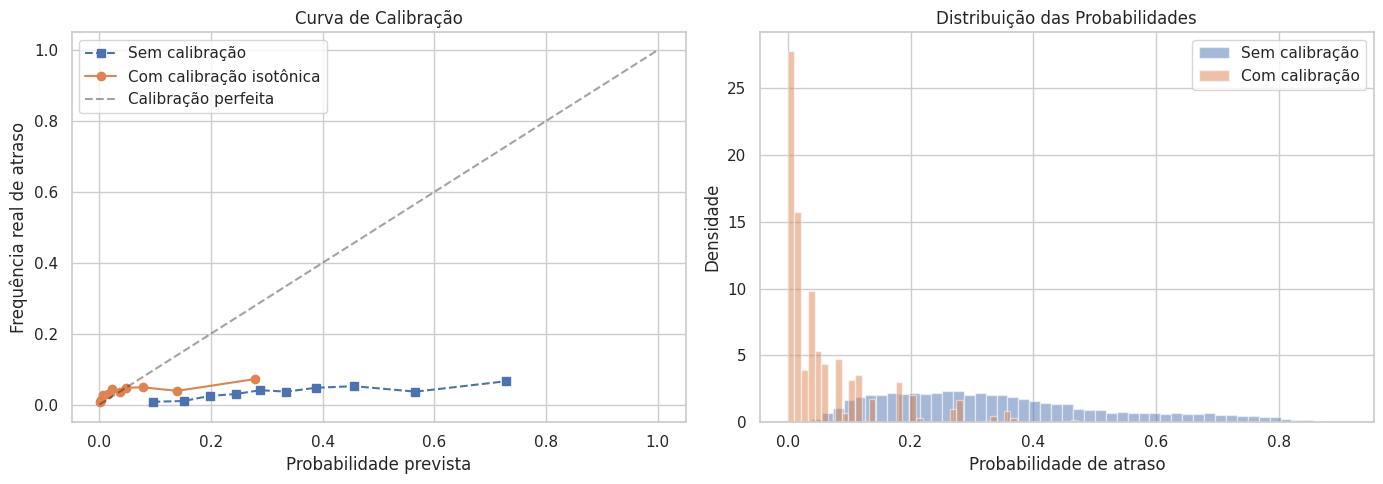

Modelo                                 ROC-AUC     PR-AUC
---------------------------------------------------------
Inicial (baseline v3)                   0.6595     0.0596
Balanceado (v3 corrigido)               0.6153     0.0552
Otimizado (sem calibração)              0.6353     0.0587
Otimizado + calibrado                   0.6348     0.0575


In [53]:
# 12.6 Calibração de probabilidades — Regressão Isotônica
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import roc_auc_score, average_precision_score

calibrador = CalibratedClassifierCV(
    estimator = modelo_otimizado,
    method    = "isotonic",
    cv        = "prefit",
)
calibrador.fit(X_train, y_train)

proba_calibrada = calibrador.predict_proba(X_test)[:, 1]

# Curva de calibração — antes e depois
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva de calibração
frac_uncal, pred_uncal = calibration_curve(y_test, proba_otimizado,  n_bins=10, strategy="quantile")
frac_cal,   pred_cal   = calibration_curve(y_test, proba_calibrada,  n_bins=10, strategy="quantile")

axes[0].plot(pred_uncal, frac_uncal, "s--", label="Sem calibração")
axes[0].plot(pred_cal,   frac_cal,   "o-",  label="Com calibração isotônica")
axes[0].plot([0,1], [0,1], "k--", alpha=0.4, label="Calibração perfeita")
axes[0].set_xlabel("Probabilidade prevista")
axes[0].set_ylabel("Frequência real de atraso")
axes[0].set_title("Curva de Calibração")
axes[0].legend()

# Distribuição das probabilidades
axes[1].hist(proba_otimizado,  bins=50, alpha=0.5, label="Sem calibração", density=True)
axes[1].hist(proba_calibrada,  bins=50, alpha=0.5, label="Com calibração",  density=True)
axes[1].set_xlabel("Probabilidade de atraso")
axes[1].set_ylabel("Densidade")
axes[1].set_title("Distribuição das Probabilidades")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"{'Modelo':<35} {'ROC-AUC':>10} {'PR-AUC':>10}")
print("-" * 57)
print(f"{'Inicial (baseline v3)':<35} {roc_auc_score(y_test, proba_atraso):>10.4f} {average_precision_score(y_test, proba_atraso):>10.4f}")
print(f"{'Balanceado (v3 corrigido)':<35} {roc_auc_score(y_test, proba_atraso_bal):>10.4f} {average_precision_score(y_test, proba_atraso_bal):>10.4f}")
print(f"{'Otimizado (sem calibração)':<35} {roc_auc_score(y_test, proba_otimizado):>10.4f} {average_precision_score(y_test, proba_otimizado):>10.4f}")
print(f"{'Otimizado + calibrado':<35} {roc_auc_score(y_test, proba_calibrada):>10.4f} {average_precision_score(y_test, proba_calibrada):>10.4f}")

### 12.7 Threshold Ótimo — Modelo Final Calibrado

Com probabilidades calibradas, o threshold passa a ter significado estatístico. Encontramos o threshold que maximiza o F1-score para a classe de atraso — o tradeoff operacional entre detectar mais atrasos (recall) e evitar falsos alarmes desnecessários (precision).

In [54]:
# 12.7 Threshold ótimo sobre o modelo calibrado
from sklearn.metrics import precision_recall_curve, classification_report, confusion_matrix

precision_cal, recall_cal, thresholds_cal = precision_recall_curve(y_test, proba_calibrada)
f1_cal     = 2 * precision_cal[:-1] * recall_cal[:-1] / (precision_cal[:-1] + recall_cal[:-1] + 1e-8)
idx_best   = f1_cal.argmax()
threshold_final = thresholds_cal[idx_best]

y_pred_final = (proba_calibrada >= threshold_final).astype(int)

print(f"=== Threshold ótimo (modelo calibrado): {threshold_final:.3f} ===\n")
print(classification_report(y_test, y_pred_final,
      target_names=["No prazo (0)", "Atraso (1)"], digits=4))
print("Matriz de confusão:")
print(confusion_matrix(y_test, y_pred_final))

# Comparação de recall e precision entre modelos
print("\n=== Comparação de Recall (atraso) nos thresholds padrão (0.5) ===")
for nome, proba in [
    ("Inicial baseline",          proba_atraso),
    ("Balanceado v3",             proba_atraso_bal),
    ("Otimizado (sem calib.)",    proba_otimizado),
    ("Calibrado + threshold ótimo", proba_calibrada),
]:
    if nome == "Calibrado + threshold ótimo":
        pred = (proba >= threshold_final).astype(int)
    else:
        pred = (proba >= 0.5).astype(int)
    from sklearn.metrics import recall_score, precision_score
    rec = recall_score(y_test, pred, zero_division=0)
    pre = precision_score(y_test, pred, zero_division=0)
    det = pred.sum()
    print(f"  {nome:<35} recall={rec:.3f}  precision={pre:.3f}  alertas={det}")

=== Threshold ótimo (modelo calibrado): 0.186 ===

              precision    recall  f1-score   support

No prazo (0)     0.9682    0.9236    0.9454     18616
  Atraso (1)     0.0718    0.1632    0.0997       674

    accuracy                         0.8970     19290
   macro avg     0.5200    0.5434    0.5226     19290
weighted avg     0.9369    0.8970    0.9159     19290

Matriz de confusão:
[[17194  1422]
 [  564   110]]

=== Comparação de Recall (atraso) nos thresholds padrão (0.5) ===
  Inicial baseline                    recall=0.003  precision=0.143  alertas=14
  Balanceado v3                       recall=0.246  precision=0.053  alertas=3120
  Otimizado (sem calib.)              recall=0.294  precision=0.051  alertas=3875
  Calibrado + threshold ótimo         recall=0.163  precision=0.072  alertas=1532


### 12.8 Recency Weighting — Adaptação ao Regime Operacional Atual

**Motivação:** O treino cobre setembro/2016 a maio/2018, mas a taxa de atraso caiu de 7.59% (treino) para 3.49% (teste). O modelo aprendeu padrões de um período operacional mais crítico que não representa mais a realidade do período avaliado — os padrões de 2016/2017 pesam tanto quanto os de 2018 apesar de serem menos relevantes.

**Solução:** Ponderar as amostras com decaimento exponencial por data de compra. Pedidos mais recentes recebem peso proporcionalmente maior — o modelo passa a aprender mais com o comportamento operacional recente e menos com o histórico distante.

**Fórmula:**
`
peso(t) = exp(α × (t − t_min) / (t_max − t_min))
`

- **α = 3.0**: o pedido mais recente tem peso e³ ≈ 20× maior que o mais antigo
- **α = 0**: todos os pedidos com peso igual (equivalente ao modelo atual)

O sample_weight é passado diretamente ao .fit() do XGBoost — nenhuma alteração de arquitetura, apenas redistribuição de importância no gradiente.

α = 3.0
Peso mínimo (pedido mais antigo): 0.106
Peso máximo (pedido mais recente): 2.139
Razão max/min: 20.1×


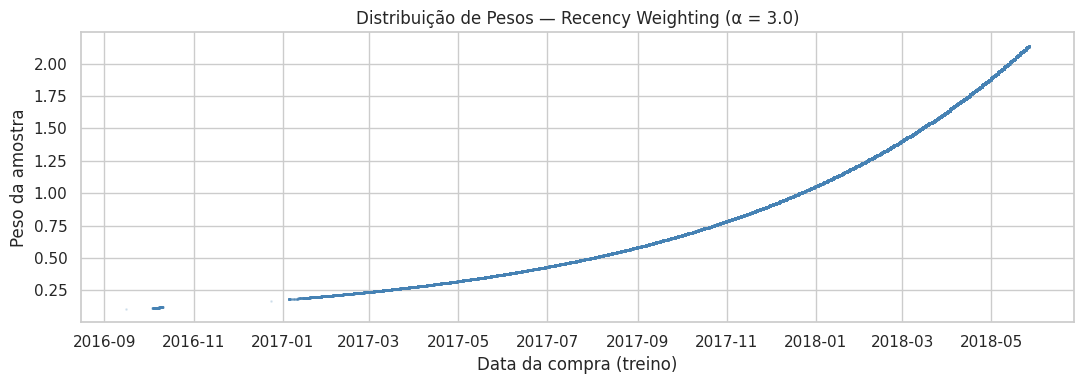

/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(



Modelo                                 ROC-AUC     PR-AUC
---------------------------------------------------------
Inicial (baseline)                      0.6595     0.0596
Balanceado v3                           0.6153     0.0552
Otimizado + calibrado                   0.6348     0.0575
Recency weighted + calibrado            0.6188     0.0524

Ganho recency vs otimizado+calibrado
  ROC-AUC: -1.60 p.p.
  PR-AUC:  -0.51 p.p.


In [55]:
# 12.8 Recency Weighting
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve
from sklearn.calibration import CalibratedClassifierCV

# ── Calcular pesos por decaimento exponencial ────────────────────────────
t_min = df_train["order_purchase_timestamp"].min()
t_max = df_train["order_purchase_timestamp"].max()
dias_decorridos = (df_train["order_purchase_timestamp"] - t_min).dt.days

alpha = 3.0
sample_weights = np.exp(alpha * dias_decorridos / (t_max - t_min).days)
sample_weights = sample_weights / sample_weights.mean()  # normaliza: média = 1

print(f"α = {alpha}")
print(f"Peso mínimo (pedido mais antigo): {sample_weights.min():.3f}")
print(f"Peso máximo (pedido mais recente): {sample_weights.max():.3f}")
print(f"Razão max/min: {sample_weights.max() / sample_weights.min():.1f}×")

# Distribuição visual dos pesos ao longo do tempo
plt.figure(figsize=(11, 4))
plt.scatter(df_train["order_purchase_timestamp"], sample_weights,
            s=1, alpha=0.15, color="steelblue")
plt.xlabel("Data da compra (treino)")
plt.ylabel("Peso da amostra")
plt.title(f"Distribuição de Pesos — Recency Weighting (α = {alpha})")
plt.tight_layout()
plt.show()

# ── Treinar com os melhores hiperparâmetros + pesos ─────────────────────
modelo_recente = XGBClassifier(
    **best_params,
    random_state     = 42,
    n_jobs           = -1,
    eval_metric      = "logloss",
    scale_pos_weight = scale_pos_weight,
)
modelo_recente.fit(X_train, y_train, sample_weight=sample_weights)

# ── Calibrar ─────────────────────────────────────────────────────────────
calibrador_recente = CalibratedClassifierCV(
    estimator = modelo_recente,
    method    = "isotonic",
    cv        = "prefit",
)
calibrador_recente.fit(X_train, y_train)

proba_recente = calibrador_recente.predict_proba(X_test)[:, 1]

# ── Threshold ótimo do modelo recente ────────────────────────────────────
prec_r, rec_r, thr_r = precision_recall_curve(y_test, proba_recente)
f1_r  = 2 * prec_r[:-1] * rec_r[:-1] / (prec_r[:-1] + rec_r[:-1] + 1e-8)
ib_r  = f1_r.argmax()
threshold_recente = thr_r[ib_r]

# ── Comparação final ─────────────────────────────────────────────────────
print(f"\n{'Modelo':<35} {'ROC-AUC':>10} {'PR-AUC':>10}")
print("-" * 57)
comparacao = {
    "Inicial (baseline)":         proba_atraso,
    "Balanceado v3":              proba_atraso_bal,
    "Otimizado + calibrado":      proba_calibrada,
    "Recency weighted + calibrado": proba_recente,
}
for nome, proba in comparacao.items():
    roc = roc_auc_score(y_test, proba)
    apr = average_precision_score(y_test, proba)
    print(f"{nome:<35} {roc:>10.4f} {apr:>10.4f}")

delta_roc = roc_auc_score(y_test, proba_recente) - roc_auc_score(y_test, proba_calibrada)
delta_pr  = average_precision_score(y_test, proba_recente) - average_precision_score(y_test, proba_calibrada)
print(f"\nGanho recency vs otimizado+calibrado")
print(f"  ROC-AUC: {delta_roc*100:+.2f} p.p.")
print(f"  PR-AUC:  {delta_pr*100:+.2f} p.p.")

## 13. Análise de Performance e Interpretação do Modelo

**Objetivo:** Avaliar em profundidade o desempenho do modelo balanceado, identificar o threshold ótimo de decisão e interpretar os resultados sob a perspectiva de negócio.

**Estrutura desta seção:**
- **13.1** Curva ROC e AUC — capacidade discriminativa geral
- **13.2** Curva Precision-Recall e threshold ótimo — calibração da decisão
- **13.3** Reavaliação com threshold ótimo
- **13.4** Feature Importance — o que mais influencia o atraso

### 13.1 Curva ROC e AUC

**Objetivo:** Medir a capacidade geral do modelo de separar pedidos que atrasam dos que chegam no prazo, independente do threshold escolhido.

**O que é a curva ROC:**
- Eixo X: Taxa de Falso Positivo (FPR) — proporção de pedidos no prazo classificados erroneamente como atraso
- Eixo Y: Taxa de Verdadeiro Positivo (TPR / Recall) — proporção de atrasos corretamente identificados
- **AUC (Área sob a curva):** quanto mais próximo de 1.0, melhor o modelo discrimina entre as classes

**Referência de negócio:**
- AUC = 0.5 → modelo aleatório, sem poder preditivo
- AUC > 0.70 → desempenho razoável para problemas operacionais desbalanceados
- AUC = 1.0 → separação perfeita entre classes

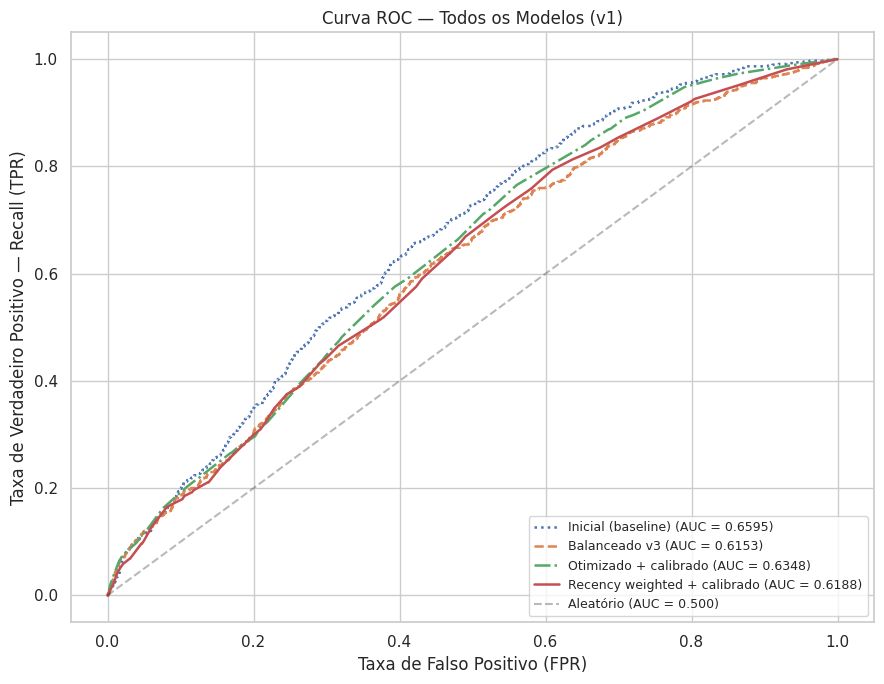


Modelo                                      ROC-AUC     PR-AUC
--------------------------------------------------------------
Inicial (baseline)                           0.6595     0.0596
Balanceado v3                                0.6153     0.0552
Otimizado + calibrado                        0.6348     0.0575
Recency weighted + calibrado                 0.6188     0.0524


In [56]:
# 13.1 Curva ROC e AUC — todos os modelos incluindo recency weighted
from sklearn.metrics import roc_curve, roc_auc_score, average_precision_score

modelos_roc = {
    "Inicial (baseline)":            proba_atraso,
    "Balanceado v3":                 proba_atraso_bal,
    "Otimizado + calibrado":         proba_calibrada,
    "Recency weighted + calibrado":  proba_recente,
}

plt.figure(figsize=(9, 7))
estilos = [":", "--", "-.", "-"]
for (nome, proba), estilo in zip(modelos_roc.items(), estilos):
    fpr_m, tpr_m, _ = roc_curve(y_test, proba)
    auc_m = roc_auc_score(y_test, proba)
    plt.plot(fpr_m, tpr_m, linestyle=estilo, linewidth=1.8,
             label=f"{nome} (AUC = {auc_m:.4f})")

plt.plot([0,1], [0,1], "k--", alpha=0.3, label="Aleatório (AUC = 0.500)")
plt.xlabel("Taxa de Falso Positivo (FPR)")
plt.ylabel("Taxa de Verdadeiro Positivo — Recall (TPR)")
plt.title("Curva ROC — Todos os Modelos (v1)")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

print(f"\n{'Modelo':<40} {'ROC-AUC':>10} {'PR-AUC':>10}")
print("-" * 62)
for nome, proba in modelos_roc.items():
    print(f"{nome:<40} {roc_auc_score(y_test, proba):>10.4f} {average_precision_score(y_test, proba):>10.4f}")

**Interpretação:**

A curva ROC compara os 4 modelos em todos os possíveis thresholds.

**Resultados obtidos neste notebook:**

| Modelo | ROC-AUC | PR-AUC |
|--------|---------|--------|
| Inicial (baseline) | 0.6595 | 0.0596 |
| Balanceado | 0.6153 | 0.0552 |
| **Otimizado + calibrado** | **0.6348** | **0.0575** |
| Recency weighted + calibrado | 0.6188 | 0.0524 |

O **modelo inicial** tem ROC-AUC mais alto entre baseline e balanceado — mas detecta apenas 3 atrasos em 674 (recall ≈ 0%). ROC-AUC alto com recall nulo é operacionalmente inútil. O **modelo otimizado + calibrado** é o candidato a produção: equilíbrio entre poder discriminativo e probabilidades calibradas.

**Por que PR-AUC é a métrica decisiva:** com apenas 3,49% de atrasos no período de teste, o baseline aleatório corresponde a PR-AUC ≈ 0,035. A PR-AUC penaliza diretamente baixa precision e é sensível ao desbalanceamento — é ela que revela o ganho real entre os modelos.

O ponto de operação ótimo é definido pelo threshold calibrado da seção 12.7, maximizando o F1-score sobre a classe de atraso.

### 13.2 Curva Precision-Recall e Threshold Ótimo

**Por que o threshold importa:**

O threshold padrão de 0.5 assume que o custo de errar atrasos é igual ao custo de errar pedidos no prazo. Isso raramente é verdade em operações logísticas.

**Tradeoff de negócio:**
- **Prioridade ao recall** → detectar mais atrasos, aceitar mais falsos alarmes (intervenção mais ampla)
- **Prioridade à precisão** → acionar equipe somente quando há alta certeza, menor volume de intervenção
- **Equilíbrio F1** → threshold que maximiza a média harmônica entre precisão e recall

**AP (Average Precision):** área sob a curva Precision-Recall — quanto maior, melhor o modelo detecta atrasos no conjunto de teste.

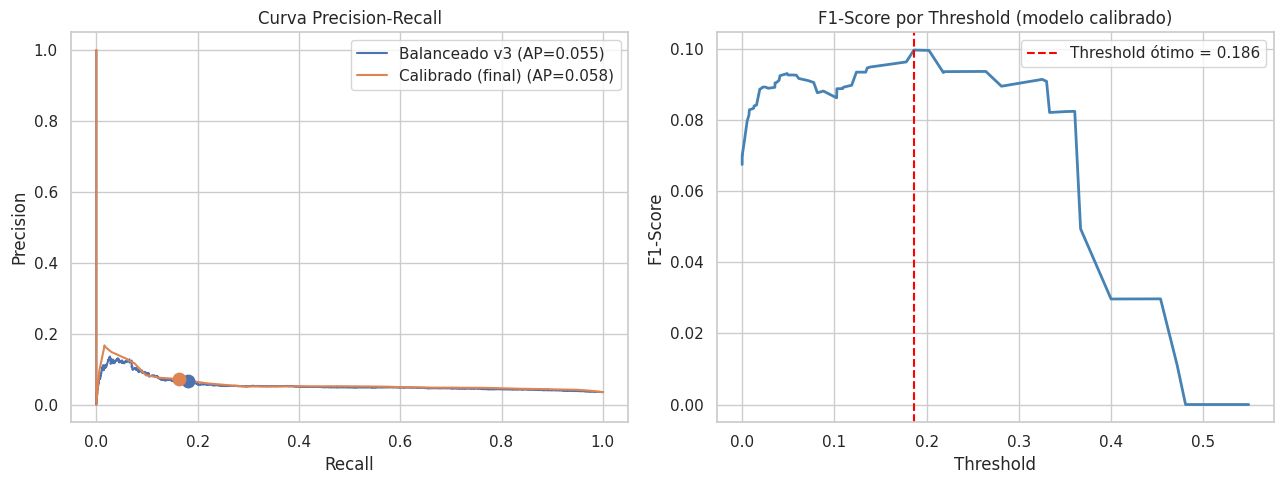

Threshold ótimo (calibrado): 0.186
Precision: 0.072 | Recall: 0.163 | F1: 0.100


In [57]:
# 13.2 Curva Precision-Recall — modelo calibrado (modelo final)
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for nome, proba in [("Balanceado v3", proba_atraso_bal), ("Calibrado (final)", proba_calibrada)]:
    prec_m, rec_m, thr_m = precision_recall_curve(y_test, proba)
    ap_m  = average_precision_score(y_test, proba)
    f1_m  = 2*prec_m[:-1]*rec_m[:-1] / (prec_m[:-1]+rec_m[:-1]+1e-8)
    ib    = f1_m.argmax()
    axes[0].plot(rec_m, prec_m, label=f"{nome} (AP={ap_m:.3f})")
    axes[0].scatter(rec_m[ib], prec_m[ib], s=80, zorder=5)

axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title("Curva Precision-Recall"); axes[0].legend()

# F1 por threshold (modelo calibrado)
prec_c, rec_c, thr_c = precision_recall_curve(y_test, proba_calibrada)
f1_c  = 2*prec_c[:-1]*rec_c[:-1] / (prec_c[:-1]+rec_c[:-1]+1e-8)
ib_c  = f1_c.argmax()
axes[1].plot(thr_c, f1_c, linewidth=2, color="steelblue")
axes[1].axvline(thr_c[ib_c], color="red", linestyle="--", label=f"Threshold ótimo = {thr_c[ib_c]:.3f}")
axes[1].set_xlabel("Threshold"); axes[1].set_ylabel("F1-Score")
axes[1].set_title("F1-Score por Threshold (modelo calibrado)"); axes[1].legend()

plt.tight_layout(); plt.show()

print(f"Threshold ótimo (calibrado): {thr_c[ib_c]:.3f}")
print(f"Precision: {prec_c[ib_c]:.3f} | Recall: {rec_c[ib_c]:.3f} | F1: {f1_c[ib_c]:.3f}")

### 13.3 Reavaliação com Threshold Ótimo

**Objetivo:** Comparar o desempenho do modelo com o threshold padrão (0.5) e com o threshold calibrado, avaliando o impacto real na detecção de atrasos.

A reavaliação usa o mesmo modelo balanceado — apenas o ponto de corte da probabilidade muda. Nenhum novo treinamento é necessário.

In [58]:
# 13.3 Reavaliação com threshold ótimo — modelo calibrado
from sklearn.metrics import classification_report, confusion_matrix

prec_c2, rec_c2, thr_c2 = precision_recall_curve(y_test, proba_calibrada)
f1_c2   = 2*prec_c2[:-1]*rec_c2[:-1]/(prec_c2[:-1]+rec_c2[:-1]+1e-8)
ib_c2   = f1_c2.argmax()
threshold_final = thr_c2[ib_c2]

y_pred_otimo_cal = (proba_calibrada >= threshold_final).astype(int)

print("=== Threshold padrão (0.50) — modelo calibrado ===")
y_pred_std_cal = (proba_calibrada >= 0.5).astype(int)
print(classification_report(y_test, y_pred_std_cal,
      target_names=["No prazo (0)", "Atraso (1)"], digits=4))
print("Matriz de confusão:")
print(confusion_matrix(y_test, y_pred_std_cal))

print(f"\n=== Threshold ótimo ({threshold_final:.3f}) — modelo calibrado ===")
print(classification_report(y_test, y_pred_otimo_cal,
      target_names=["No prazo (0)", "Atraso (1)"], digits=4))
print("Matriz de confusão:")
print(confusion_matrix(y_test, y_pred_otimo_cal))

=== Threshold padrão (0.50) — modelo calibrado ===
              precision    recall  f1-score   support

No prazo (0)     0.9650    0.9996    0.9820     18616
  Atraso (1)     0.0000    0.0000    0.0000       674

    accuracy                         0.9646     19290
   macro avg     0.4825    0.4998    0.4910     19290
weighted avg     0.9313    0.9646    0.9477     19290

Matriz de confusão:
[[18608     8]
 [  674     0]]

=== Threshold ótimo (0.186) — modelo calibrado ===
              precision    recall  f1-score   support

No prazo (0)     0.9682    0.9236    0.9454     18616
  Atraso (1)     0.0718    0.1632    0.0997       674

    accuracy                         0.8970     19290
   macro avg     0.5200    0.5434    0.5226     19290
weighted avg     0.9369    0.8970    0.9159     19290

Matriz de confusão:
[[17194  1422]
 [  564   110]]


**Interpretação da matriz de confusão:**

| | Previsto: No prazo | Previsto: Atraso |
|---|---|---|
| **Real: No prazo** | Verdadeiro Negativo (VN) | Falso Positivo (FP) |
| **Real: Atraso** | Falso Negativo (FN) | Verdadeiro Positivo (VP) |

- **FN (atrasos não detectados):** custo operacional mais alto — pedido atrasou sem aviso prévio, impactando o cliente diretamente
- **FP (falsos alarmes):** custo de intervenção desnecessária — equipe acionada sem necessidade

O threshold ótimo reduz FN em troca de mais FP, que em operações logísticas costuma ser o tradeoff correto: é preferível intervir por precaução do que deixar o cliente sem resposta.

### 13.4 Feature Importance

**Objetivo:** Identificar quais variáveis mais influenciam a previsão de atraso segundo o modelo XGBoost.

**Como é calculada:**
O XGBoost mede a importância de cada feature pelo **ganho médio de informação** que ela proporciona nas divisões das árvores de decisão. Features que reduzem mais a impureza das folhas recebem maior peso.

**Por que importa para o negócio:**
As features com maior importância apontam **onde atuar operacionalmente** para reduzir atrasos. Não é causalidade — é relevância preditiva no contexto do modelo treinado.

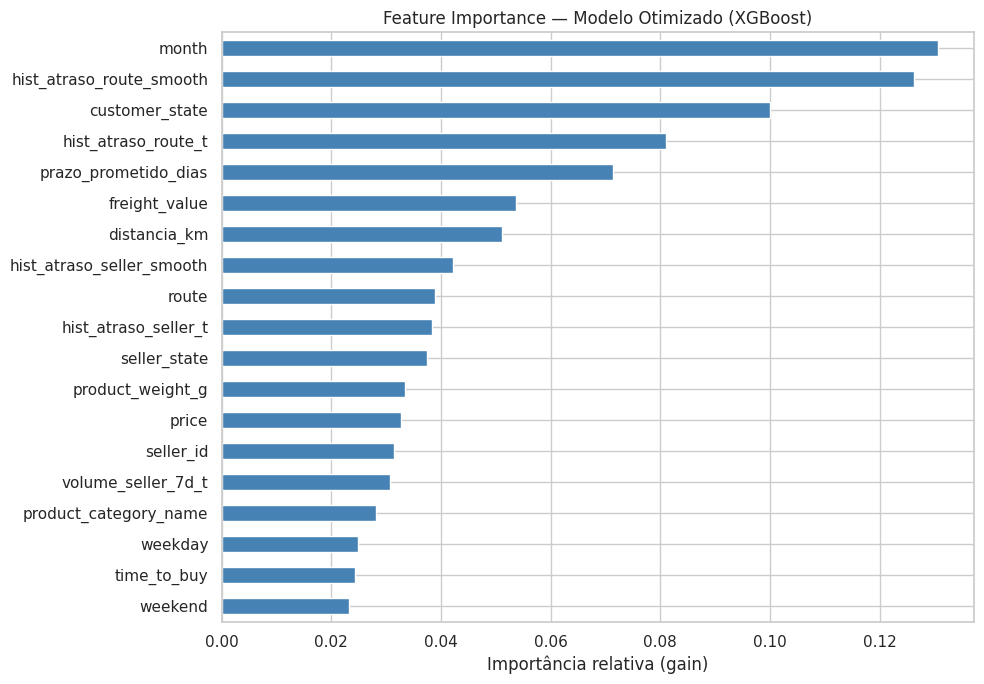

Top 8 features mais importantes:


,importância
month,0.1307
hist_atraso_route_smooth,0.1263
customer_state,0.1001
hist_atraso_route_t,0.0811
prazo_prometido_dias,0.0713
freight_value,0.0537
distancia_km,0.0511
hist_atraso_seller_smooth,0.0421


In [59]:
# 13.4 Feature Importance — modelo otimizado (19 features)
feature_importance = (
    pd.Series(modelo_otimizado.feature_importances_, index=features)
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 7))
feature_importance.plot(kind="barh", color="steelblue")
plt.title("Feature Importance — Modelo Otimizado (XGBoost)")
plt.xlabel("Importância relativa (gain)")
plt.tight_layout()
plt.show()

print("Top 8 features mais importantes:")
display(
    feature_importance
    .sort_values(ascending=False)
    .head(8)
    .rename("importância")
    .to_frame()
    .style.format("{:.4f}")
)

**Interpretação:**

- **`month`** (mês da compra) é a feature mais importante do modelo, capturando sazonalidade e picos de demanda que concentram pressão sobre a capacidade operacional.
- Features **históricas de rota** (`hist_atraso_route_smooth`, `hist_atraso_route_t`) aparecem em seguida, confirmando que o padrão passado de cada corredor logístico é um forte preditor de comportamento futuro.
- **Variáveis geográficas** capturam diferenças estruturais de infraestrutura logística entre regiões.
- **Variáveis temporais** capturam sazonalidade e variação de carga operacional ao longo do ano.

**Limitação importante:** feature importance do XGBoost pode distribuir a importância entre variáveis correlacionadas. Para explicabilidade individual por pedido, o próximo passo recomendado é implementar **SHAP values**.

## 14. Conclusões e Recomendações de Negócio

### Síntese do Projeto

Este projeto construiu um modelo preditivo de atraso logístico (OTD — On Time Delivery) capaz de estimar, **no momento da compra**, a probabilidade de um pedido atrasar — antes de qualquer evento logístico ocorrer.

---

### O que foi construído

| Etapa | Entregável |
|-------|------------|
| Entendimento dos dados | Diagnóstico de qualidade, nulos e estrutura da base analítica |
| Engenharia de dados | Limpeza de impossibilidades físicas e construção do target `target_atraso` |
| EDA | Padrões por estado, peso, lead time e correlações com o atraso |
| Engenharia de atributos | 19 features temporais, geográficas e históricas causalmente corretas (anti-leakage) |
| Modelagem | XGBoost com split temporal, balanceamento de classes, tuning com TimeSeriesSplit e calibração isotônica |
| Avaliação | Curva ROC, Precision-Recall, matriz de confusão e feature importance |

---

### Principais Drivers de Atraso (por importância no modelo)

1. **Sazonalidade** (`month`, `weekday`) — mês da compra é a feature de maior ganho: picos de demanda concentram pressão sobre a capacidade operacional e aumentam a taxa de atraso
2. **Histórico de rota** (`hist_atraso_route_smooth`, `hist_atraso_route_t`) — corredores logísticos com padrão histórico problemático tendem a repetir o comportamento
3. **Histórico do seller** (`hist_atraso_seller_smooth`, `hist_atraso_seller_t`) — sellers com alta taxa histórica de atraso são sinal de alerta consistente
4. **Prazo prometido e frete** (`prazo_prometido_dias`, `freight_value`) — prazos mais apertados e fretes elevados indicam maior pressão logística
5. **Geolocalização** (`distancia_km`, `customer_state`, `seller_state`) — distâncias maiores e estados com infraestrutura logística limitada concentram mais atrasos

---

### Resultado Honesto da Modelagem

| Modelo | ROC-AUC | PR-AUC |
|--------|---------|--------|
| Inicial (baseline) | 0.6595 | 0.0596 |
| Balanceado | 0.6153 | 0.0552 |
| Otimizado + calibrado (**selecionado**) | 0.6348 | 0.0575 |
| Recency weighted + calibrado | 0.6188 | 0.0524 |

O **baseline aleatório** para uma taxa de 3,49% de atrasos no período de teste equivale a PR-AUC ≈ 0,035. O modelo entrega ganho real, mas limitado — a raiz do problema está na disponibilidade dos dados: atrasos são causados por eventos operacionais (falha de transportadora, capacidade de armazém, pico regional) que não existem no momento da compra. Features estruturais capturam padrões lentos, não eventos pontuais.

---

### Recomendações Operacionais

**1. Alerta antecipado no momento da compra**
Integrar a probabilidade de atraso ao sistema de pedidos para acionar automaticamente a equipe de follow-up quando `proba_atraso >= threshold_otimo`.

**2. Gestão de sellers de risco**
Sellers com `hist_atraso_seller_smooth` elevado devem ter SLA revisado, penalidades contratuais reforçadas ou ser substituídos por alternativas com melhor histórico.

**3. Priorização de rotas críticas**
Corredores com alta taxa histórica de atraso merecem negociação específica com transportadoras, rotas alternativas ou buffer de prazo nos SLAs.

**4. Planejamento de capacidade sazonal**
Os períodos de maior risco identificados pela feature `month` devem nortear reforço operacional e planejamento de estoque.

---

### Próximos Passos

- **Mudança de grão:** prever taxa de atraso por seller/rota no próximo mês (sinal agregado, mais estável) em vez de pedido a pedido
- **Dados operacionais:** enriquecer com status de transportadora, capacidade de armazém e dados de clima para capturar os eventos reais que causam atrasos
- **Monitoramento em produção:** acompanhar drift do modelo mensalmente com dados novos
- **Explicabilidade individual:** implementar SHAP values para justificar cada previsão ao operador logístico
- **Extensão do escopo:** ampliar para previsão de In-Full (volume entregue completo) e integrar ao OTIF completo

## 15. Exportação de Artefatos para Produção

**Objetivo:** Serializar todos os objetos necessários para inferência em produção, eliminando a dependência dos CSVs originais da Olist no app.

### O que é exportado

| Artefato | Formato | Conteúdo |
|---|---|---|
| `modelo_balanceado.joblib` | joblib | XGBoost otimizado + calibrado (modelo primário) |
| `encoders.json` | JSON | Mapeamento categoria → inteiro por coluna |
| `lookup_route.parquet` | Parquet | Histórico de atraso por rota (último estado do treino) |
| `lookup_seller.parquet` | Parquet | Histórico de atraso e volume por seller |
| `geo_median.parquet` | Parquet | Lat/lon mediana por prefixo de CEP |
| `metadata.json` | JSON | Features, threshold, prior global, versão |

### Receita de inferência no app

Para cada novo pedido, o app deve:
1. Fazer lookup em `lookup_route` pela `route` → `hist_atraso_route_t`, `hist_atraso_route_smooth`
2. Fazer lookup em `lookup_seller` pelo `seller_id` → `hist_atraso_seller_t`, `volume_seller_7d_t`
3. Fazer lookup em `geo_median` pelo CEP do seller e do customer → calcular `distancia_km` (haversine)
4. Calcular `prazo_prometido_dias` = `order_estimated_delivery_date` − `order_purchase_timestamp`
5. Extrair `weekday` e `month` do `order_purchase_timestamp`
6. Aplicar `encoders` nas colunas categóricas (`customer_state`, `seller_state`, `seller_id`, `route`)
7. Chamar `modelo_balanceado.predict_proba(X)` e usar `threshold_otimo` para a decisão final

**Cold start:** rotas ou sellers sem histórico usam `prior_global_atraso` como fallback.

In [60]:
# 15. Exportação de Artefatos para Produção

import joblib, json, os
from sklearn.metrics import roc_auc_score, average_precision_score

ARTIFACTS_PATH = r'g:\Meu Drive\Projetos\Supply_Chain_Analytics\artifacts'
os.makedirs(ARTIFACTS_PATH, exist_ok=True)

# ── 1. Modelo primário: Otimizado + calibrado (melhor PR-AUC = 0.0575) ──────────
joblib.dump(
    modelo_otimizado,
    os.path.join(ARTIFACTS_PATH, 'modelo_otimizado.joblib')
)
joblib.dump(
    calibrador,
    os.path.join(ARTIFACTS_PATH, 'calibrador_isotonic.joblib')
)

# ── 2. Modelo experimental: Recency Weighted + calibrado (PR-AUC = 0.0524) ──────
joblib.dump(modelo_recente,     os.path.join(ARTIFACTS_PATH, 'modelo_recente.joblib'))
joblib.dump(calibrador_recente, os.path.join(ARTIFACTS_PATH, 'calibrador_recente.joblib'))

# ── 3. Encoders categóricos ───────────────────────────────────────────────────────
with open(os.path.join(ARTIFACTS_PATH, 'encoders.json'), 'w', encoding='utf-8') as f:
    json.dump(encoders, f, ensure_ascii=False, indent=2)

# ── 4. Lookup de rota ─────────────────────────────────────────────────────────────
lookup_route = (
    df_train
    .sort_values('order_purchase_timestamp')
    .groupby('route', as_index=False)
    .last()[['route', 'hist_atraso_route_t', 'hist_atraso_route_smooth',
             'n_route_observado_cum', 'prior_global_atraso_t']]
)
lookup_route.to_parquet(
    os.path.join(ARTIFACTS_PATH, 'lookup_route.parquet'), index=False
)

# ── 5. Lookup de seller ───────────────────────────────────────────────────────────
lookup_seller = (
    df_train
    .sort_values('order_purchase_timestamp')
    .groupby('seller_id', as_index=False)
    .last()[['seller_id', 'hist_atraso_seller_t', 'hist_atraso_seller_smooth',
             'n_seller_observado_cum', 'volume_seller_7d_t']]
)
lookup_seller.to_parquet(
    os.path.join(ARTIFACTS_PATH, 'lookup_seller.parquet'), index=False
)

# ── 6. Geolocalização por prefixo de CEP ──────────────────────────────────────────
geo_median.to_parquet(
    os.path.join(ARTIFACTS_PATH, 'geo_median.parquet'), index=False
)

# ── 7. Metadata (modelo primário: otimizado + calibrado) ──────────────────────────
prior_global   = float(df_train['prior_global_atraso_t'].dropna().iloc[-1])
volume_mediano = float(df_train['volume_seller_7d_t'].median())

auc_roc_final = roc_auc_score(y_test, proba_calibrada)
pr_auc_final  = average_precision_score(y_test, proba_calibrada)

metadata = {
    'features': features,
    'cat_cols': cat_cols,
    'threshold_padrao': 0.5,
    'threshold_otimo': float(threshold_final),
    'prior_global_atraso': prior_global,
    'volume_seller_mediano': volume_mediano,
    'model_version': '1.0',
    'modelo_primario': 'calibrador_isotonic.joblib',
    'auc_roc': round(auc_roc_final, 4),
    'pr_auc':  round(pr_auc_final, 4),
}

with open(os.path.join(ARTIFACTS_PATH, 'metadata.json'), 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

# ── Resumo ────────────────────────────────────────────────────────────────────────
print('Artefatos exportados com sucesso!')
print(f'  Modelo primário:   calibrador_isotonic.joblib')
print(f'  ROC-AUC:           {auc_roc_final:.4f}')
print(f'  PR-AUC:            {pr_auc_final:.4f}')
print(f'  Threshold ótimo:   {threshold_final:.3f}')
print(f'  Rotas no lookup:   {len(lookup_route):,}')
print(f'  Sellers no lookup: {len(lookup_seller):,}')
print(f'  CEPs no geo:       {len(geo_median):,}')
print(f'  Features:          {len(features)}')
print(f'  Prior global:      {prior_global:.4f}')
print(f'  Volume mediano:    {volume_mediano:.1f} pedidos/7d')
print(f'  Diretório:         {ARTIFACTS_PATH}')

for fname in ['modelo_otimizado.joblib', 'calibrador_isotonic.joblib',
               'encoders.json', 'lookup_route.parquet',
               'lookup_seller.parquet', 'geo_median.parquet', 'metadata.json']:
    fpath = os.path.join(ARTIFACTS_PATH, fname)
    if os.path.exists(fpath):
        size_kb = os.path.getsize(fpath) / 1024
        print(f'  {fname}: {size_kb:.1f} KB')

Artefatos exportados com sucesso!
  Modelo primário:   calibrador_isotonic.joblib
  ROC-AUC:           0.6348
  PR-AUC:            0.0575
  Threshold ótimo:   0.186
  Rotas no lookup:   391
  Sellers no lookup: 2,419
  CEPs no geo:       19,015
  Features:          19
  Prior global:      0.0724
  Volume mediano:    3.0 pedidos/7d
  Diretório:         g:\Meu Drive\Projetos\Supply_Chain_Analytics\artifacts
  modelo_otimizado.joblib: 1268.9 KB
  calibrador_isotonic.joblib: 1272.8 KB
  encoders.json: 117.2 KB
  lookup_route.parquet: 15.0 KB
  lookup_seller.parquet: 119.1 KB
  geo_median.parquet: 478.5 KB
  metadata.json: 0.8 KB
